# ✈️ NASA C-MAPSS FD002 — 전처리 파이프라인 → DL 통합 노트북

**구성:** CONFIG → 파이프라인 함수 → 실행 → DL 모델 학습/평가/MLflow

파라미터는 최상단 CONFIG 셀에서만 조절.

## 0. CONFIG

In [2]:
# ============================================================
# 🔧 CONFIG — 모든 파이프라인 파라미터를 여기서 조절
# ============================================================
CONFIG = {
    # 센서 추가 수동 제거 (예: ['s_5','s_9']). 빈 리스트면 자동제거만 적용
    'manual_remove_sensors': [],

    # RUL Cap (120 / 125 / 130)
    'rul_cap': 125,

    # Gaussian sigma (None=skip / 1 / 2 / 3)
    'gaussian_sigma': 2,

    # 정규화 방식 ('minmax' / 'standard')
    'normalize': 'minmax',

    # ── 시계열 파생변수 (원하는 만큼 리스트로) ──
    'lags':         [10],     # 예: [] / [1] / [1,2] / [1,3,5,10] ...
    'diffs':        [1],           # 차분 윈도우
    'rolling_means':[5],        # rolling mean 윈도우들
    'rolling_stds': [10],        # rolling std 윈도우들
    'emas':         [10],           # EMA span (정수)
}

# 슬라이딩 윈도우 (DL 용)
WINDOW_SIZE = 30
STEP        = 1

# 클러스터 / 기타 상수
N_CLUSTERS = 6
CONST_THR  = 0.01
RANDOM_STATE = 42
VALID_RATIO  = 0.2

print('✅ CONFIG 로드 완료')
for k,v in CONFIG.items():
    print(f'   {k:22s}: {v}')


✅ CONFIG 로드 완료
   manual_remove_sensors : []
   rul_cap               : 125
   gaussian_sigma        : 2
   normalize             : minmax
   lags                  : [10]
   diffs                 : [1]
   rolling_means         : [5]
   rolling_stds          : [10]
   emas                  : [10]


## 1. 환경 / 라이브러리

In [3]:
import os, warnings, json, platform
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split

warnings.filterwarnings('ignore')

if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':
    plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

# ── 컬럼 정의 ─────────────────────────────────────────────────────────
RAW_COLS = ['unit','cycle','op1','op2','op3'] + [f's{i}' for i in range(1, 22)]
RENAME_MAP = {
    'unit':'unit_nr', 'cycle':'time_cycles',
    'op1':'setting_1', 'op2':'setting_2', 'op3':'setting_3',
    **{f's{i}': f's_{i}' for i in range(1, 22)}
}
SENSOR_COLS = [f's_{i}' for i in range(1, 22)]
OP_COLS     = ['setting_1','setting_2','setting_3']
ID_COLS     = ['unit_nr','time_cycles']

print('✅ 라이브러리 로드 완료')


✅ 라이브러리 로드 완료


## 2. FD002 원본 데이터 로딩

In [4]:
# FD002 원본 데이터 로딩
DATA_DIR = 'CMAPSSData'
for c in ['CMAPSSData', './CMAPSSData', '../CMAPSSData']:
    if os.path.exists(os.path.join(c, 'train_FD002.txt')):
        DATA_DIR = c; break

kw = dict(sep=r'\s+', header=None, names=RAW_COLS, engine='python')
train_raw = pd.read_csv(f'{DATA_DIR}/train_FD002.txt', **kw)
test_raw  = pd.read_csv(f'{DATA_DIR}/test_FD002.txt',  **kw)
rul_df    = pd.read_csv(f'{DATA_DIR}/RUL_FD002.txt',
                        sep=r'\s+', header=None, names=['RUL'], engine='python')
train_raw.rename(columns=RENAME_MAP, inplace=True)
test_raw.rename(columns=RENAME_MAP,  inplace=True)

print(f'✅ FD002 로딩  Train:{train_raw.shape}  Test:{test_raw.shape}  RUL:{rul_df.shape}')


✅ FD002 로딩  Train:(53759, 26)  Test:(33991, 26)  RUL:(259, 1)


## 3. 전처리 파이프라인 함수

In [5]:
# ============================================================
# 🔧 파이프라인 함수 정의 (검증/시각화 없이 핵심 로직만)
# ============================================================

def filter_useful_sensors(train_df, sensor_cols, manual_remove, const_thr=CONST_THR):
    """상수 센서 자동 제거 + 수동 제거 = 최종 유용 센서 리스트"""
    train_std = train_df[sensor_cols].std()
    auto_remove = set(train_std[train_std < const_thr].index.tolist())
    manual_set  = set(manual_remove or [])
    remove = sorted(auto_remove | manual_set, key=lambda x: int(x.split('_')[1]))
    useful = sorted([s for s in sensor_cols if s not in remove],
                    key=lambda x: int(x.split('_')[1]))
    return useful, remove


def add_op_cluster(train_df, test_df, op_cols, k, random_state=42):
    """KMeans로 운전조건 클러스터링 (train fit → test predict)"""
    km = KMeans(n_clusters=k, random_state=random_state, n_init=20, max_iter=300)
    km.fit(train_df[op_cols])
    train_df = train_df.copy()
    test_df  = test_df.copy()
    train_df['op_cluster'] = km.labels_
    test_df['op_cluster']  = km.predict(test_df[op_cols])
    return train_df, test_df, km


def add_piecewise_rul(df, cap):
    """엔진별 RUL 계산 후 cap 적용"""
    df = df.copy()
    mc = df.groupby('unit_nr')['time_cycles'].max().rename('max_c')
    df = df.join(mc, on='unit_nr')
    df['RUL_raw'] = df['max_c'] - df['time_cycles']
    df['RUL']     = df['RUL_raw'].clip(upper=cap)
    return df.drop('max_c', axis=1)


def apply_gaussian_by_cluster(df, features, sigma):
    """엔진×클러스터 단위 Gaussian 스무딩"""
    df = df.copy().sort_values(['unit_nr','op_cluster','time_cycles']).reset_index(drop=True)
    for uid in df['unit_nr'].unique():
        u_mask = df['unit_nr'] == uid
        for c in df.loc[u_mask, 'op_cluster'].unique():
            uc_mask = u_mask & (df['op_cluster'] == c)
            idx = df[uc_mask].index
            for s in features:
                arr = df.loc[idx, s].values.astype(np.float32)
                if len(arr) > 1:
                    df.loc[idx, s] = gaussian_filter1d(arr, sigma=sigma, mode='nearest')
    return df


def split_by_unit(train_df, valid_ratio=VALID_RATIO, random_state=RANDOM_STATE):
    """엔진단위 random split (누수 방지)"""
    units = train_df['unit_nr'].unique()
    sub_units, val_units = train_test_split(units, test_size=valid_ratio,
                                            random_state=random_state)
    sub = train_df[train_df['unit_nr'].isin(sub_units)].copy().reset_index(drop=True)
    val = train_df[train_df['unit_nr'].isin(val_units)].copy().reset_index(drop=True)
    return sub, val, sub_units, val_units


def normalize_by_cluster(sub, val, test, features, method, n_clusters):
    """클러스터별 정규화 (sub-train fit → val/test transform)"""
    ScalerCls = {'minmax': MinMaxScaler, 'standard': StandardScaler}[method]
    scalers = {}
    sub  = sub.copy(); val = val.copy(); test = test.copy()
    for c in range(n_clusters):
        mask = sub['op_cluster'] == c
        scaler_c = ScalerCls()
        if mask.sum() == 0:
            scaler_c.fit(sub[features])
        else:
            sub.loc[mask, features] = scaler_c.fit_transform(sub.loc[mask, features])
        scalers[c] = scaler_c
    for df_target in [val, test]:
        for c in range(n_clusters):
            mask = df_target['op_cluster'] == c
            if mask.sum() > 0:
                df_target.loc[mask, features] = scalers[c].transform(df_target.loc[mask, features])
    return sub, val, test, scalers


def add_temporal_features_by_cluster(df, sensor_cols,
                                      lags, diffs, rolls, roll_stds, emas):
    """엔진×클러스터 단위 시계열 파생변수 (CONFIG 리스트 만큼 동적 생성)"""
    df = df.sort_values(['unit_nr','op_cluster','time_cycles']).copy()
    for s in sensor_cols:
        grp = df.groupby(['unit_nr','op_cluster'])[s]
        for lag in (lags or []):
            df[f'{s}_lag{lag}'] = grp.shift(lag)
        for d in (diffs or []):
            df[f'{s}_diff{d}'] = grp.diff(d)
        for r in (rolls or []):
            df[f'{s}_roll{r}'] = grp.transform(lambda x: x.rolling(r, min_periods=1).mean())
        for r in (roll_stds or []):
            df[f'{s}_rollstd{r}'] = grp.transform(lambda x: x.rolling(r, min_periods=1).std().fillna(0))
        for span in (emas or []):
            df[f'{s}_ema{span}'] = grp.transform(lambda x: x.ewm(span=span, adjust=False).mean())
    return df.fillna(0)


def add_ohe_cluster(df, n_clusters):
    """op_cluster 원핫인코딩 후 concat"""
    ohe_cols = [f'cluster_{i}' for i in range(n_clusters)]
    ohe = pd.get_dummies(df['op_cluster'], prefix='cluster').astype(np.float32)
    for col in ohe_cols:
        if col not in ohe.columns:
            ohe[col] = np.float32(0.0)
    return pd.concat([df.reset_index(drop=True),
                      ohe[ohe_cols].reset_index(drop=True)], axis=1), ohe_cols


def create_sliding_windows(df, feature_cols, target_col=None,
                           window_size=WINDOW_SIZE, step=STEP):
    X_list, y_list = [], []
    for uid in np.sort(df['unit_nr'].unique()):
        udf  = df[df['unit_nr']==uid].sort_values('time_cycles')
        data = udf[feature_cols].values.astype(np.float32)
        tgt  = udf[target_col].values if target_col else None
        n = len(data)
        for start in range(0, n - window_size + 1, step):
            end = start + window_size
            X_list.append(data[start:end])
            if tgt is not None:
                y_list.append(tgt[end-1])
    X = np.array(X_list, dtype=np.float32)
    y = np.array(y_list, dtype=np.float32) if y_list else None
    return X, y


def create_test_windows(df, feature_cols, rul_series, window_size=WINDOW_SIZE):
    X_list, y_list = [], []
    for i, uid in enumerate(np.sort(df['unit_nr'].unique())):
        udf  = df[df['unit_nr']==uid].sort_values('time_cycles')
        data = udf[feature_cols].values.astype(np.float32)
        if len(data) >= window_size:
            X_list.append(data[-window_size:])
        else:
            pad = np.zeros((window_size - len(data), len(feature_cols)), dtype=np.float32)
            X_list.append(np.vstack([pad, data]))
        y_list.append(float(rul_series.iloc[i]))
    return np.array(X_list, dtype=np.float32), np.array(y_list, dtype=np.float32)


def run_pipeline(train_raw, test_raw, cfg):
    """전체 파이프라인 실행 → 모든 산출물 dict 반환"""
    # 1. 상수 + 수동 센서 제거
    useful, removed = filter_useful_sensors(train_raw, SENSOR_COLS,
                                            cfg['manual_remove_sensors'])
    print(f'[1] 센서 필터링: 제거 {len(removed)}개 → 유지 {len(useful)}개')
    print(f'    제거: {removed}')

    keep = ID_COLS + OP_COLS + useful
    tr1 = train_raw[keep].copy()
    te1 = test_raw[keep].copy()

    # 2. 운전조건 클러스터링
    tr2, te2, kmeans = add_op_cluster(tr1, te1, OP_COLS, N_CLUSTERS, RANDOM_STATE)
    print(f'[2] 운전조건 클러스터링 완료 (k={N_CLUSTERS})')

    # 3. Piecewise RUL
    tr3 = add_piecewise_rul(tr2, cap=cfg['rul_cap'])
    te3 = te2.copy()
    print(f'[3] Piecewise RUL  cap={cfg["rul_cap"]}')

    # 4. Gaussian (옵션)
    if cfg['gaussian_sigma'] is not None and cfg['gaussian_sigma'] > 0:
        tr4 = apply_gaussian_by_cluster(tr3, useful, sigma=cfg['gaussian_sigma'])
        te4 = apply_gaussian_by_cluster(te3, useful, sigma=cfg['gaussian_sigma'])
        print(f'[4] Gaussian σ={cfg["gaussian_sigma"]} 적용')
    else:
        tr4 = tr3; te4 = te3
        print('[4] Gaussian skip')

    # 5. Validation split (엔진단위)
    sub5, val5, sub_units, val_units = split_by_unit(tr4, VALID_RATIO, RANDOM_STATE)
    test5 = te4.copy()
    print(f'[5] Split  sub={len(sub_units)}대 / val={len(val_units)}대')

    # 6. 클러스터별 정규화
    sub6, val6, test6, scalers = normalize_by_cluster(
        sub5, val5, test5, useful, cfg['normalize'], N_CLUSTERS)
    print(f'[6] 정규화 ({cfg["normalize"]}) — 클러스터별 6개 scaler')

    # 7. 시계열 파생변수
    sub7 = add_temporal_features_by_cluster(
        sub6, useful,
        cfg['lags'], cfg['diffs'], cfg['rolling_means'],
        cfg['rolling_stds'], cfg['emas'])
    val7 = add_temporal_features_by_cluster(
        val6, useful,
        cfg['lags'], cfg['diffs'], cfg['rolling_means'],
        cfg['rolling_stds'], cfg['emas'])
    test7 = add_temporal_features_by_cluster(
        test6, useful,
        cfg['lags'], cfg['diffs'], cfg['rolling_means'],
        cfg['rolling_stds'], cfg['emas'])
    EXCLUDE = set(ID_COLS + OP_COLS + ['op_cluster','RUL','RUL_raw'])
    ml_features = [c for c in sub7.columns if c not in EXCLUDE]
    print(f'[7] 파생변수 생성  ML features={len(ml_features)}개')

    # 8. OHE
    sub8, ohe_cols = add_ohe_cluster(sub7, N_CLUSTERS)
    val8, _        = add_ohe_cluster(val7, N_CLUSTERS)
    test8, _       = add_ohe_cluster(test7, N_CLUSTERS)
    ml_features = ml_features + ohe_cols
    print(f'[8] OHE 추가  최종 ML features={len(ml_features)}개')

    return {
        'subtrain_ml': sub8,
        'valid_ml':    val8,
        'test_ml':     test8,
        'useful_sensors': useful,
        'ohe_cols':    ohe_cols,
        'ml_features': ml_features,
        'dl_features': useful + ohe_cols,
        'scalers':     scalers,
        'kmeans':      kmeans,
        'sub_units':   sub_units,
        'val_units':   val_units,
    }

print('✅ 파이프라인 함수 정의 완료')


✅ 파이프라인 함수 정의 완료


## 4. 파이프라인 실행

In [6]:
# ============================================================
# 🚀 파이프라인 실행
# ============================================================
data = run_pipeline(train_raw, test_raw, CONFIG)

subtrain_ml    = data['subtrain_ml']
valid_ml       = data['valid_ml']
test_ml        = data['test_ml']
USEFUL_SENSORS = data['useful_sensors']
OHE_COLS       = data['ohe_cols']
ML_FEATURES    = data['ml_features']
DL_FEATURES    = data['dl_features']

print(f'\nSub-train: {subtrain_ml.shape}  Valid: {valid_ml.shape}  Test: {test_ml.shape}')
print(f'ML_FEATURES: {len(ML_FEATURES)}개   DL_FEATURES: {len(DL_FEATURES)}개')


[1] 센서 필터링: 제거 1개 → 유지 20개
    제거: ['s_16']
[2] 운전조건 클러스터링 완료 (k=6)
[3] Piecewise RUL  cap=125
[4] Gaussian σ=2 적용
[5] Split  sub=208대 / val=52대
[6] 정규화 (minmax) — 클러스터별 6개 scaler
[7] 파생변수 생성  ML features=120개
[8] OHE 추가  최종 ML features=126개

Sub-train: (43464, 134)  Valid: (10295, 134)  Test: (33991, 132)
ML_FEATURES: 126개   DL_FEATURES: 26개


## 5. DL 라이브러리 & 텐서 바인딩

In [1]:
# DL 전용 라이브러리
import time, math
from copy import deepcopy
import joblib, optuna, mlflow, mlflow.pytorch
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from optuna.samplers import TPESampler
from optuna.pruners import MedianPruner
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

optuna.logging.set_verbosity(optuna.logging.WARNING)
print('✅ DL 라이브러리 로드 완료')


✅ DL 라이브러리 로드 완료


In [7]:
# ============================================================
# 🔗 DL 모델 입력 텐서 바인딩 (CSV 거치지 않고 메모리에서 직접)
# ============================================================
RESULT_DIR      = 'results_dl'
MODEL_DIR       = 'models_dl'
MLFLOW_DIR      = 'mlruns'
EXPERIMENT_NAME = 'CMAPSS_FD002_DL'
BATCH_SIZE      = 256
N_TRIALS        = 10
EPOCHS_SEARCH   = 30
EPOCHS_FINAL    = 100
PATIENCE        = 10
PRIMARY_METRIC  = 'Val NASA(eval)'
SECONDARY_METRIC= 'Val RMSE'
CLIP_LOWER      = 0.0

os.makedirs(RESULT_DIR, exist_ok=True)
os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(MLFLOW_DIR, exist_ok=True)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.manual_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

N_FEATURES = len(DL_FEATURES)

# ── 슬라이딩 윈도우 → 3D 텐서 (메모리에서 직접 생성) ──
X_sub,  y_sub  = create_sliding_windows(subtrain_ml, DL_FEATURES, 'RUL', WINDOW_SIZE, STEP)
X_val,  y_val  = create_sliding_windows(valid_ml,    DL_FEATURES, 'RUL', WINDOW_SIZE, STEP)
X_test, y_test = create_test_windows(   test_ml,     DL_FEATURES, rul_df['RUL'], WINDOW_SIZE)

# ── val_eval: 엔진별 마지막 윈도우 (NASA Score 기준) ──
X_val_eval_list, y_val_eval_list, val_eval_units = [], [], []
for uid in np.sort(valid_ml['unit_nr'].unique()):
    udf  = valid_ml[valid_ml['unit_nr']==uid].sort_values('time_cycles')
    data = udf[DL_FEATURES].values.astype(np.float32)
    rul  = float(udf['RUL'].iloc[-1])
    if len(data) >= WINDOW_SIZE:
        window = data[-WINDOW_SIZE:]
    else:
        pad    = np.zeros((WINDOW_SIZE - len(data), N_FEATURES), dtype=np.float32)
        window = np.vstack([pad, data])
    X_val_eval_list.append(window)
    y_val_eval_list.append(rul)
    val_eval_units.append(uid)
X_val_eval = np.array(X_val_eval_list, dtype=np.float32)
y_val_eval = np.array(y_val_eval_list, dtype=np.float32)
val_eval_units = np.array(val_eval_units)

# 다크 테마 + 모델 색상 (기존 DL 노트북 호환)
BG, BG2, GRID = '#0f1117', '#1a1d2e', '#2d3148'
WHITE, GRAY   = '#ffffff', '#aaaaaa'
C = ['#00d4ff','#ff6b6b','#51cf66','#ffd43b','#a29bfe','#fd79a8','#00b894','#e17055']
plt.rcParams.update({
    'figure.facecolor':BG,'axes.facecolor':BG2,'axes.edgecolor':GRID,
    'axes.labelcolor':GRAY,'xtick.color':GRAY,'ytick.color':GRAY,
    'text.color':WHITE,'grid.color':GRID,'grid.alpha':0.4,'axes.grid':True,
    'font.size':10,'axes.titlesize':11,'legend.facecolor':BG2,'legend.edgecolor':GRID,
})
MODEL_COLORS = {
    'LSTM':C[0],'BiLSTM':C[2],'Transformer':C[1],'CNN+Transformer':C[3],
}
MODEL_NAMES = list(MODEL_COLORS.keys())

print(f'✅ DL 텐서 바인딩 완료  Device={DEVICE}')
print(f'  X_sub      : {X_sub.shape}  y_sub: {y_sub.shape}')
print(f'  X_val      : {X_val.shape}  y_val: {y_val.shape}')
print(f'  X_test     : {X_test.shape} y_test: {y_test.shape}')
print(f'  X_val_eval : {X_val_eval.shape}')
print(f'  N_FEATURES : {N_FEATURES}')


✅ DL 텐서 바인딩 완료  Device=cpu
  X_sub      : (37432, 30, 26)  y_sub: (37432,)
  X_val      : (8787, 30, 26)  y_val: (8787,)
  X_test     : (259, 30, 26) y_test: (259,)
  X_val_eval : (52, 30, 26)
  N_FEATURES : 26


---
# 🧠 딥러닝 학습 / 평가 / MLflow

*아래는 기존 DL 노트북 셀 그대로 (데이터 로드 부분만 위 바인딩으로 대체)*

## 2. 데이터 검증 — 무결성 체크 & 슬라이딩 윈도우 시각화

=== 2. 데이터 검증 ===
--- 데이터 무결성 ---


,shape,NaN(X),NaN(y),음수 RUL,X min,X max,y min,y max
구분,,,,,,,,
X_sub,"(37432, 30, 26)",0,0,0,0.0000,1.0000,0.0,125.0
X_val,"(8787, 30, 26)",0,0,0,-0.1294,1.0999,0.0,125.0
X_test,"(259, 30, 26)",0,0,0,-2.0066,1.0773,6.0,194.0



Test zero-padding: 6/259개 샘플 (2.3%)
  → 시계열 길이 < 30 사이클인 엔진에 앞쪽 zero-pad 적용됨
  → Transformer/LSTM의 src_key_padding_mask 또는 pack_padded_sequence로 처리 권장
  ※ FD001(단일 조건, sea level)은 대부분 30+ 사이클이므로 실제 패딩 비율은 낮음

--- 센서별 값 범위 요약 (X_sub, 정규화 후) ---


,min,max,mean,std
센서,,,,
s_1,0.0000,0.0000,0.0000,0.0000
s_2,0.0000,1.0000,0.4223,0.1374
s_3,0.0000,1.0000,0.4118,0.1373
s_4,0.0000,1.0000,0.4115,0.1526
s_5,0.0000,0.0000,0.0000,0.0000
s_6,0.0000,1.0000,0.4664,0.3506
s_7,0.0000,1.0000,0.5716,0.1327
s_8,0.0000,1.0000,0.2800,0.1446
s_9,0.0000,1.0000,0.1947,0.0928


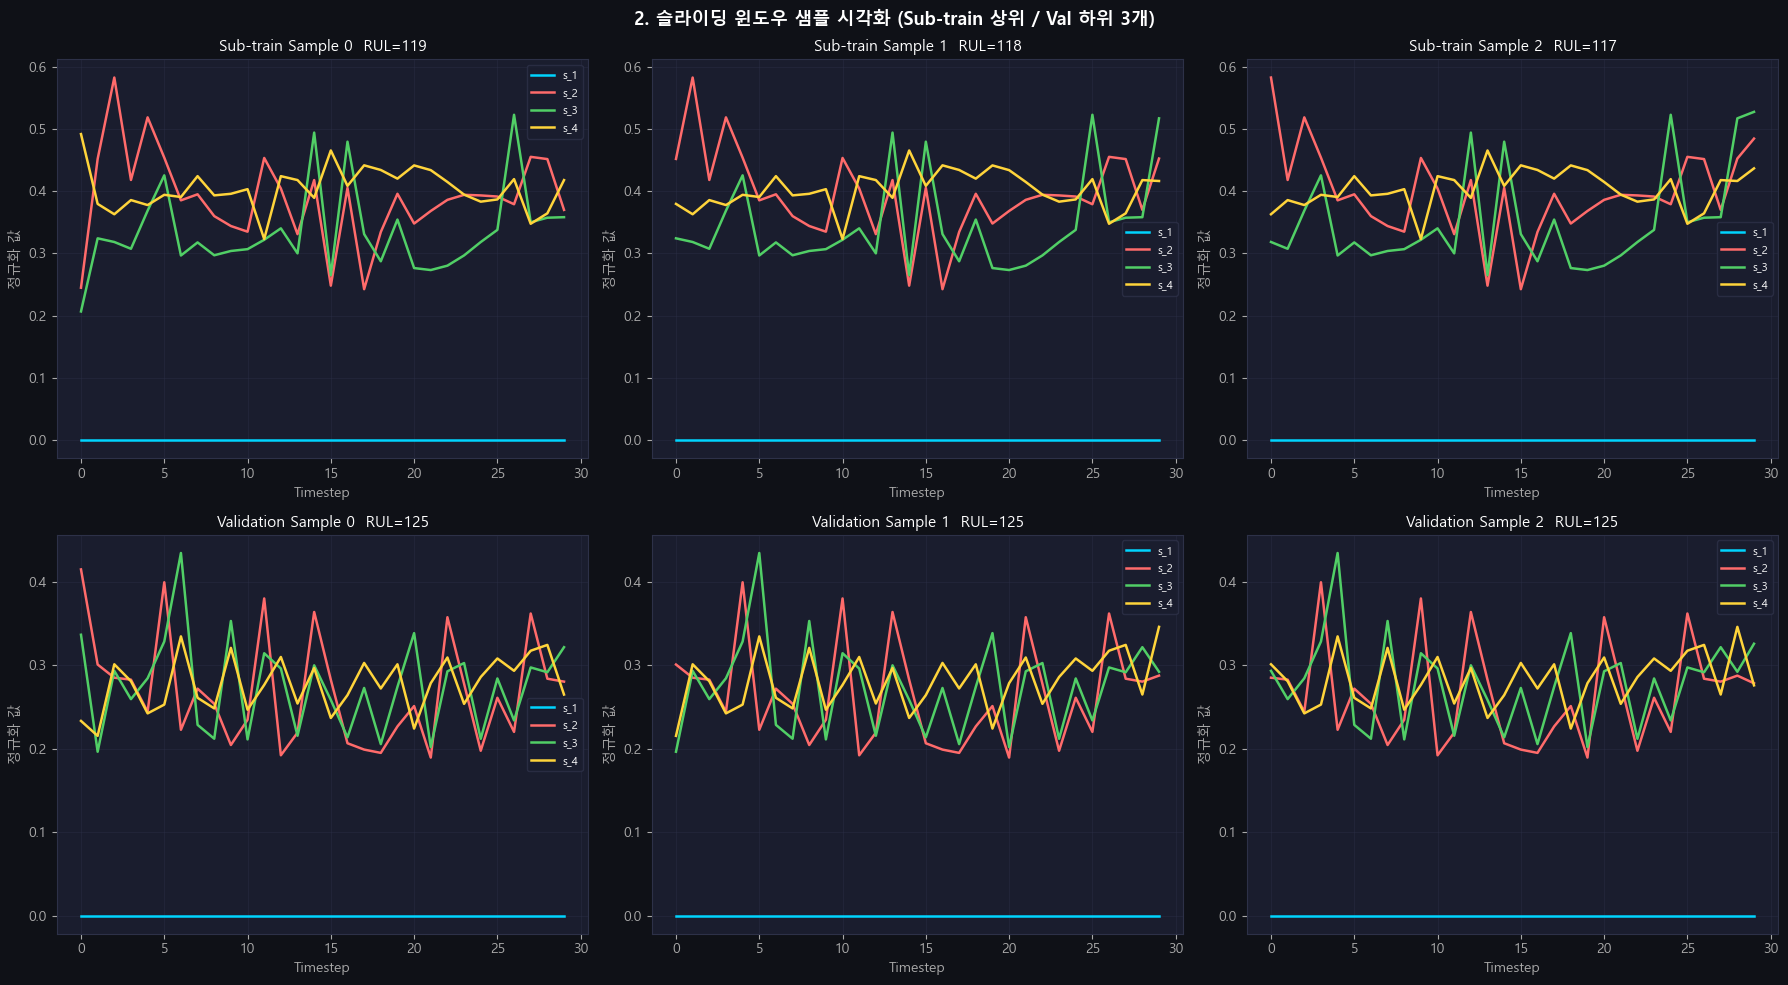

✅ 데이터 검증 완료


In [8]:
print('=== 2. 데이터 검증 ===')

# ── 무결성 검사 ───────────────────────────────────────────────────────────────
print('--- 데이터 무결성 ---')
quality_rows = []
for name, X, y in [('X_sub', X_sub, y_sub), ('X_val', X_val, y_val), ('X_test', X_test, y_test)]:
    quality_rows.append({
        '구분'       : name,
        'shape'      : str(X.shape),
        'NaN(X)'     : int(np.isnan(X).sum()),
        'NaN(y)'     : int(np.isnan(y).sum()),
        '음수 RUL'   : int((y < 0).sum()),
        'X min'      : round(float(X.min()), 4),
        'X max'      : round(float(X.max()), 4),
        'y min'      : round(float(y.min()), 1),
        'y max'      : round(float(y.max()), 1),
    })
quality_df = pd.DataFrame(quality_rows).set_index('구분')
display(quality_df)

# Test zero-padding 현황
first_ts_zero = (X_test[:, 0, :].sum(axis=1) == 0).sum()
print(f'\nTest zero-padding: {first_ts_zero}/{len(X_test)}개 샘플 ({first_ts_zero/len(X_test)*100:.1f}%)')
print('  → 시계열 길이 < 30 사이클인 엔진에 앞쪽 zero-pad 적용됨')
print('  → Transformer/LSTM의 src_key_padding_mask 또는 pack_padded_sequence로 처리 권장')
print('  ※ FD001(단일 조건, sea level)은 대부분 30+ 사이클이므로 실제 패딩 비율은 낮음')

# ── 센서 유효범위 (정규화 후 [0,1] 기대) ─────────────────────────────────────
print('\n--- 센서별 값 범위 요약 (X_sub, 정규화 후) ---')
flat_sub = X_sub.reshape(-1, N_FEATURES)
rng_df = pd.DataFrame({
    '센서'   : DL_FEATURES,
    'min'    : flat_sub.min(axis=0).round(4),
    'max'    : flat_sub.max(axis=0).round(4),
    'mean'   : flat_sub.mean(axis=0).round(4),
    'std'    : flat_sub.std(axis=0).round(4),
})
display(rng_df.set_index('센서').style.background_gradient(subset=['std'], cmap='YlOrRd').format('{:.4f}'))

# ── 윈도우 샘플 시각화 ─────────────────────────────────────────────────────────
show_feats = DL_FEATURES[:4]
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('2. 슬라이딩 윈도우 샘플 시각화 (Sub-train 상위 / Val 하위 3개)',
             fontsize=13, fontweight='bold')

for ax, sidx in zip(axes[0], [0, 1, 2]):
    for fi, fn in enumerate(show_feats):
        ax.plot(X_sub[sidx, :, DL_FEATURES.index(fn)], color=C[fi], lw=1.8, label=fn)
    ax.set_title(f'Sub-train Sample {sidx}  RUL={y_sub[sidx]:.0f}')
    ax.set_xlabel('Timestep'); ax.set_ylabel('정규화 값')
    ax.legend(fontsize=8)

for ax, sidx in zip(axes[1], [0, 1, 2]):
    for fi, fn in enumerate(show_feats):
        ax.plot(X_val[sidx, :, DL_FEATURES.index(fn)], color=C[fi], lw=1.8, label=fn)
    ax.set_title(f'Validation Sample {sidx}  RUL={y_val[sidx]:.0f}')
    ax.set_xlabel('Timestep'); ax.set_ylabel('정규화 값')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()
print('✅ 데이터 검증 완료')


## 3. 실험 설계 — Dataset / DataLoader, 평가 지표, 모델 정의, 학습 유틸리티

### 모델 아키텍처 요약

| 모델 | 특징 |
|------|------|
| **LSTM** | 단방향 LSTM, 마지막 hidden state → FC |
| **BiLSTM** | 양방향 LSTM, forward+backward concat → FC |
| **Transformer** | Linear projection + Positional Encoding + Encoder (Pre-LN) → CLS token → FC |
| **CNN+Transformer** | 1D-CNN 지역 특징 추출 → Transformer Encoder → FC |

- 모든 모델: gradient clipping (max_norm=1.0), RUL clip ≥ 0, Early Stopping  
- **모델 선택 기준**: Val NASA(eval) → Val RMSE (Test는 최종 확인용)


In [9]:
print('=== 3. 실험 설계 ===')

# ────────────────────────────────────────────────────────────────────────────
# PyTorch Dataset / DataLoader
# ────────────────────────────────────────────────────────────────────────────
class RULDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)
    def __len__(self):
        return len(self.y)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

def make_loaders(X_tr, y_tr, X_va, y_va, batch_size=BATCH_SIZE):
    pin = (DEVICE.type == 'cuda')
    tr = DataLoader(RULDataset(X_tr, y_tr), batch_size=batch_size, shuffle=True,
                    num_workers=0, pin_memory=pin)
    va = DataLoader(RULDataset(X_va, y_va), batch_size=batch_size * 2, shuffle=False,
                    num_workers=0, pin_memory=pin)
    return tr, va

tr_loader, va_loader = make_loaders(X_sub, y_sub, X_val, y_val)
print(f'DataLoader 준비 완료:')
print(f'  Sub-train : {len(tr_loader.dataset):,}개 / {len(tr_loader)}배치 (batch={BATCH_SIZE})')
print(f'  Validation: {len(va_loader.dataset):,}개 / {len(va_loader)}배치')

# ────────────────────────────────────────────────────────────────────────────
# 평가 지표
# ────────────────────────────────────────────────────────────────────────────
def clip_rul(pred):
    return np.clip(np.asarray(pred, dtype=float), CLIP_LOWER, None)

def nasa_score(y_true, y_pred):
    """비대칭 NASA Score: 조기예측 페널티(÷13) < 늦은예측 페널티(÷10)"""
    y_true = np.asarray(y_true, dtype=float)
    y_pred = clip_rul(y_pred)
    d = y_pred - y_true
    return float(np.sum(np.where(d < 0, np.exp(-d / 13) - 1, np.exp(d / 10) - 1)))

def get_metrics(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = clip_rul(y_pred)
    return {
        'RMSE'      : float(np.sqrt(mean_squared_error(y_true, y_pred))),
        'MAE'       : float(mean_absolute_error(y_true, y_pred)),
        'R2'        : float(r2_score(y_true, y_pred)),
        'NASA_Score': float(nasa_score(y_true, y_pred)),
    }

# ────────────────────────────────────────────────────────────────────────────
# 배치 예측 (no_grad)
# ────────────────────────────────────────────────────────────────────────────
@torch.no_grad()
def predict_np(model, X_np, batch_size=512):
    model.eval()
    ds  = DataLoader(torch.tensor(X_np, dtype=torch.float32), batch_size=batch_size)
    out = []
    for xb in ds:
        out.append(model(xb.to(DEVICE)).cpu().numpy())
    return np.concatenate(out)

# ────────────────────────────────────────────────────────────────────────────
# 재현성 시드 고정
# ────────────────────────────────────────────────────────────────────────────
def set_seed(seed=RANDOM_STATE):
    torch.manual_seed(seed)
    np.random.seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

# ────────────────────────────────────────────────────────────────────────────
# 학습 루프 (Early Stopping + LR Scheduler 내장)
# ────────────────────────────────────────────────────────────────────────────
def train_model(model, tr_loader, va_loader, optimizer, scheduler, epochs,
                patience=PATIENCE, verbose=False):
    """
    Returns
    -------
    history    : dict {'train_loss': [...], 'val_rmse': [...]}
    best_val   : float  (최저 val RMSE)
    best_epoch : int    (best epoch 번호, 1-indexed)
    """
    model.to(DEVICE)
    criterion  = nn.HuberLoss(delta=10.0)   # RUL 범위[0,125]에 맞게 delta 설정
    best_val   = float('inf')
    best_state = None
    best_epoch = 0
    wait       = 0
    history    = {'train_loss': [], 'val_rmse': []}

    for epoch in range(1, epochs + 1):
        # ── Train ─────────────────────────────────────────────────────────
        model.train()
        epoch_loss = 0.0
        for Xb, yb in tr_loader:
            Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad()
            pred = model(Xb)
            loss = criterion(pred, yb)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            epoch_loss += loss.item() * len(yb)
        avg_loss = epoch_loss / len(tr_loader.dataset)

        # ── Validate ──────────────────────────────────────────────────────
        val_pred = predict_np(model, X_val)
        val_rmse = float(np.sqrt(mean_squared_error(y_val, clip_rul(val_pred))))

        if scheduler is not None:
            scheduler.step(val_rmse)

        history['train_loss'].append(avg_loss)
        history['val_rmse'].append(val_rmse)

        if verbose and epoch % 10 == 0:
            print(f'  Epoch {epoch:3d} | Loss={avg_loss:.4f} | Val RMSE={val_rmse:.4f}')

        if val_rmse < best_val - 1e-5:
            best_val   = val_rmse
            best_state = deepcopy(model.state_dict())
            best_epoch = epoch
            wait       = 0
        else:
            wait += 1
            if wait >= patience:
                break

    if best_state is not None:
        model.load_state_dict(best_state)

    return history, best_val, best_epoch

# ────────────────────────────────────────────────────────────────────────────
# 모델 아키텍처 정의
# ────────────────────────────────────────────────────────────────────────────

# ── Positional Encoding ───────────────────────────────────────────────────────
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, dropout=0.1, max_len=500):
        super().__init__()
        self.dropout = nn.Dropout(p=dropout)
        pe  = torch.zeros(max_len, d_model)
        pos = torch.arange(0, max_len).unsqueeze(1).float()
        div = torch.exp(
            torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model)
        )
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div[:pe[:, 1::2].shape[1]])
        self.register_buffer('pe', pe.unsqueeze(0))   # (1, max_len, d_model)

    def forward(self, x):
        return self.dropout(x + self.pe[:, :x.size(1)])

# ── LSTM ──────────────────────────────────────────────────────────────────────
class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, dropout, fc_size):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size, hidden_size, num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0
        )
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Sequential(
            nn.Linear(hidden_size, fc_size), nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(fc_size, 1)
        )

    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(self.dropout(out[:, -1, :])).squeeze(-1)

# ── BiLSTM ────────────────────────────────────────────────────────────────────
class BiLSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, dropout, fc_size):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size, hidden_size, num_layers,
            batch_first=True, bidirectional=True,
            dropout=dropout if num_layers > 1 else 0.0
        )
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Sequential(
            nn.Linear(hidden_size * 2, fc_size), nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(fc_size, 1)
        )

    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(self.dropout(out[:, -1, :])).squeeze(-1)

# ── Transformer ───────────────────────────────────────────────────────────────
class TransformerModel(nn.Module):
    def __init__(self, input_size, d_model, nhead, num_layers, dim_feedforward, dropout):
        super().__init__()
        self.input_proj = nn.Linear(input_size, d_model)
        self.pos_enc    = PositionalEncoding(d_model, dropout)
        enc_layer = nn.TransformerEncoderLayer(
            d_model, nhead, dim_feedforward, dropout,
            batch_first=True, norm_first=True          # Pre-LN (학습 안정)
        )
        self.encoder = nn.TransformerEncoder(enc_layer, num_layers,
                                              norm=nn.LayerNorm(d_model))
        self.fc = nn.Sequential(
            nn.Linear(d_model, max(d_model // 2, 16)), nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(max(d_model // 2, 16), 1)
        )

    def forward(self, x):
        x = self.pos_enc(self.input_proj(x))
        x = self.encoder(x)
        return self.fc(x[:, -1, :]).squeeze(-1)   # 마지막 타임스텝 token

# ── CNN + Transformer ────────────────────────────────────────────────────────
class CNNTransformerModel(nn.Module):
    def __init__(self, input_size, cnn_channels, kernel_size,
                 d_model, nhead, num_layers, dropout):
        super().__init__()
        # Conv1d: [B, F, T]
        self.cnn = nn.Sequential(
            nn.Conv1d(input_size, cnn_channels, kernel_size,
                      padding=kernel_size // 2, bias=False),
            nn.BatchNorm1d(cnn_channels),
            nn.GELU(),
            nn.Conv1d(cnn_channels, d_model, kernel_size,
                      padding=kernel_size // 2, bias=False),
            nn.BatchNorm1d(d_model),
            nn.GELU(),
        )
        self.pos_enc = PositionalEncoding(d_model, dropout)
        enc_layer = nn.TransformerEncoderLayer(
            d_model, nhead, d_model * 2, dropout,
            batch_first=True, norm_first=True
        )
        self.encoder = nn.TransformerEncoder(enc_layer, num_layers,
                                              norm=nn.LayerNorm(d_model))
        self.fc = nn.Sequential(
            nn.Linear(d_model, max(d_model // 2, 16)), nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(max(d_model // 2, 16), 1)
        )

    def forward(self, x):
        # x: [B, T, F] → permute → CNN → permute → Transformer
        x = self.cnn(x.permute(0, 2, 1)).permute(0, 2, 1)
        x = self.pos_enc(x)
        x = self.encoder(x)
        return self.fc(x[:, -1, :]).squeeze(-1)

# ── 파라미터 수 출력 ────────────────────────────────────────────────────────────
for name, m in [
    ('LSTM (h=128, L=2)', LSTMModel(N_FEATURES, 128, 2, 0.2, 64)),
    ('BiLSTM (h=128, L=2)', BiLSTMModel(N_FEATURES, 128, 2, 0.2, 64)),
    ('Transformer (d=64, h=4, L=2)', TransformerModel(N_FEATURES, 64, 4, 2, 128, 0.1)),
    ('CNN+Transformer (d=64, h=4, L=2)', CNNTransformerModel(N_FEATURES, 64, 3, 64, 4, 2, 0.1)),
]:
    n = sum(p.numel() for p in m.parameters())
    print(f'  {name:42s}: {n:,} params')

print('\n✅ 모델 정의 및 학습 유틸리티 준비 완료')


=== 3. 실험 설계 ===
DataLoader 준비 완료:
  Sub-train : 37,432개 / 147배치 (batch=256)
  Validation: 8,787개 / 18배치
  LSTM (h=128, L=2)                         : 220,289 params
  BiLSTM (h=128, L=2)                       : 571,521 params
  Transformer (d=64, h=4, L=2)              : 70,913 params
  CNN+Transformer (d=64, h=4, L=2)          : 86,721 params

✅ 모델 정의 및 학습 유틸리티 준비 완료


## 4. MLflow 설정

In [10]:
print('=== 4. MLflow 설정 ===')

os.makedirs(MLFLOW_DIR, exist_ok=True)
tracking_uri = Path(MLFLOW_DIR).resolve().as_uri()
mlflow.set_tracking_uri(tracking_uri)
mlflow.set_experiment(EXPERIMENT_NAME)

if mlflow.active_run() is not None:
    mlflow.end_run()

PARENT_RUN = mlflow.start_run(run_name='FD001_DL_parent')
mlflow.log_params({
    'dataset'         : 'FD001',
    'split_strategy'  : 'GroupShuffleSplit(random_state=42) — 전처리 노트북 산출물',
    'window_size'     : WINDOW_SIZE,
    'n_features'      : N_FEATURES,
    'batch_size'      : BATCH_SIZE,
    'n_trials'        : N_TRIALS,
    'epochs_search'   : EPOCHS_SEARCH,
    'epochs_final'    : EPOCHS_FINAL,
    'patience'        : PATIENCE,
    'clip_lower'      : CLIP_LOWER,
    'device'          : str(DEVICE),
    'loss_fn'         : 'HuberLoss(delta=10)',
    'optimizer'       : 'Adam',
    'lr_scheduler'    : 'ReduceLROnPlateau(patience=7, factor=0.5)',
})

print(f'Tracking URI : {mlflow.get_tracking_uri()}')
print(f'Experiment   : {EXPERIMENT_NAME}')
print(f'Parent Run ID: {PARENT_RUN.info.run_id}')
print('✅ MLflow 준비 완료')

ALL_RESULTS  = {}   # 전체 결과 저장
BEST_MODELS  = {}   # 최적 모델 저장


2026/04/26 10:07:01 INFO mlflow.tracking.fluent: Experiment with name 'CMAPSS_FD002_DL' does not exist. Creating a new experiment.


=== 4. MLflow 설정 ===
Tracking URI : file:///C:/python_course/4project_cmapss/SH/mlruns
Experiment   : CMAPSS_FD002_DL
Parent Run ID: 8662fc0ba39c4b93906935f03ae202a5
✅ MLflow 준비 완료


## 5. LSTM 학습 (Optuna + MLflow)

**탐색 공간:**

| 파라미터 | 범위 |
|----------|------|
| `hidden_size` | 64, 128, 256 |
| `num_layers` | 1 ~ 3 |
| `dropout` | 0.1 ~ 0.5 |
| `fc_size` | 32, 64, 128 |
| `lr` | 1e-4 ~ 1e-2 (log) |
| `weight_decay` | 1e-6 ~ 1e-3 (log) |


=== 5. LSTM 학습 (Optuna) ===


  0%|          | 0/10 [00:00<?, ?it/s]


최적 파라미터: {'hidden_size': 64, 'num_layers': 1, 'dropout': 0.2243929286862649, 'fc_size': 64, 'lr': 0.0059487468132197715, 'weight_decay': 2.6100256506134754e-05}
  Epoch  10 | Loss=81.4916 | Val RMSE=15.8539
  Epoch  20 | Loss=68.9204 | Val RMSE=12.4266
  Epoch  30 | Loss=59.9558 | Val RMSE=11.3586


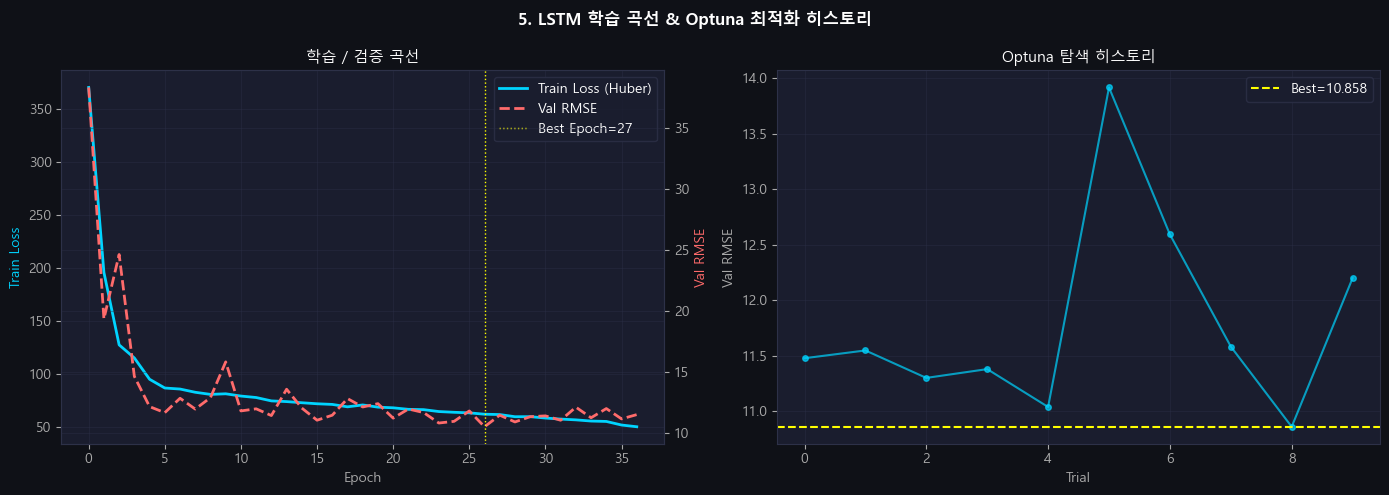


[LSTM] 완료 (78초) | Val RMSE=10.533 | Val NASA(eval)=30.1 | Test RMSE=28.415 | Test NASA=17670.9 | Params=27,777


In [11]:
print('=== 5. LSTM 학습 (Optuna) ===')
MODEL_NAME = 'LSTM'

# ── Optuna 목적 함수 ──────────────────────────────────────────────────────────
best_lstm_state = {'val': float('inf'), 'state': None, 'params': None, 'trial_obj': None}

def lstm_objective(trial):
    hidden = trial.suggest_categorical('hidden_size', [64, 128, 256])
    layers = trial.suggest_int('num_layers', 1, 3)
    drop   = trial.suggest_float('dropout', 0.1, 0.5)
    fc     = trial.suggest_categorical('fc_size', [32, 64, 128])
    lr     = trial.suggest_float('lr', 1e-4, 1e-2, log=True)
    wd     = trial.suggest_float('weight_decay', 1e-6, 1e-3, log=True)

    set_seed(RANDOM_STATE + trial.number)
    model = LSTMModel(N_FEATURES, hidden, layers, drop, fc).to(DEVICE)
    opt   = optim.Adam(model.parameters(), lr=lr, weight_decay=wd)
    sch   = optim.lr_scheduler.ReduceLROnPlateau(opt, patience=5, factor=0.5)

    _, val_rmse, _ = train_model(model, tr_loader, va_loader, opt, sch, EPOCHS_SEARCH)

    if val_rmse < best_lstm_state['val']:
        best_lstm_state['val']      = val_rmse
        best_lstm_state['state']    = deepcopy(model.state_dict())
        best_lstm_state['params']   = trial.params
        best_lstm_state['trial_obj'] = trial

    return val_rmse

study_lstm = optuna.create_study(direction='minimize',
                                  sampler=TPESampler(seed=RANDOM_STATE),
                                  pruner=MedianPruner(n_warmup_steps=5))
study_lstm.optimize(lstm_objective, n_trials=N_TRIALS, show_progress_bar=True)
best_p = study_lstm.best_params
print(f'\n최적 파라미터: {best_p}')

# ── 최적 파라미터로 최종 학습 ─────────────────────────────────────────────────
set_seed(RANDOM_STATE)
lstm_model = LSTMModel(N_FEATURES,
                        best_p['hidden_size'], best_p['num_layers'],
                        best_p['dropout'],     best_p['fc_size']).to(DEVICE)
opt_final = optim.Adam(lstm_model.parameters(),
                        lr=best_p['lr'], weight_decay=best_p['weight_decay'])
sch_final = optim.lr_scheduler.ReduceLROnPlateau(opt_final, patience=7, factor=0.5)

t0 = time.time()
hist_lstm, _, best_ep_lstm = train_model(
    lstm_model, tr_loader, va_loader, opt_final, sch_final, EPOCHS_FINAL, verbose=True)
elapsed_lstm = time.time() - t0

# ── 메트릭 계산 ───────────────────────────────────────────────────────────────
val_pred_lstm      = predict_np(lstm_model, X_val)
val_eval_pred_lstm = predict_np(lstm_model, X_val_eval)
test_pred_lstm     = predict_np(lstm_model, X_test)

val_metrics_lstm   = get_metrics(y_val,      val_pred_lstm)
val_eval_nasa_lstm = nasa_score(y_val_eval,  val_eval_pred_lstm)
test_metrics_lstm  = get_metrics(y_test,     test_pred_lstm)
n_params_lstm = sum(p.numel() for p in lstm_model.parameters())

ALL_RESULTS['LSTM'] = {
    'model'        : lstm_model,
    'params'       : best_p,
    'history'      : hist_lstm,
    'best_epoch'   : best_ep_lstm,
    'val_metrics'  : val_metrics_lstm,
    'val_eval_nasa': val_eval_nasa_lstm,
    'test_metrics' : test_metrics_lstm,
    'fit_seconds'  : elapsed_lstm,
    'n_params'     : n_params_lstm,
    'study'        : study_lstm,
}
BEST_MODELS['LSTM'] = lstm_model

# ── MLflow 기록 ───────────────────────────────────────────────────────────────
with mlflow.start_run(run_name='LSTM', nested=True):
    mlflow.set_tags({'model_family': 'rnn', 'model_name': 'LSTM'})
    mlflow.log_params({**best_p, 'n_params': n_params_lstm,
                       'best_epoch': best_ep_lstm, 'fit_seconds': round(elapsed_lstm,1)})
    mlflow.log_metrics({
        'val_rmse': val_metrics_lstm['RMSE'],   'val_mae': val_metrics_lstm['MAE'],
        'val_r2'  : val_metrics_lstm['R2'],     'val_nasa': val_metrics_lstm['NASA_Score'],
        'val_eval_nasa': val_eval_nasa_lstm,
        'test_rmse': test_metrics_lstm['RMSE'], 'test_mae': test_metrics_lstm['MAE'],
        'test_r2'  : test_metrics_lstm['R2'],   'test_nasa': test_metrics_lstm['NASA_Score'],
    })
    torch.save(lstm_model.state_dict(), os.path.join(MODEL_DIR, 'LSTM_best.pt'))
    mlflow.log_artifact(os.path.join(MODEL_DIR, 'LSTM_best.pt'))

# ── 학습 곡선 시각화 ───────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('5. LSTM 학습 곡선 & Optuna 최적화 히스토리', fontsize=12, fontweight='bold')

axes[0].plot(hist_lstm['train_loss'], color=C[0], lw=2, label='Train Loss (Huber)')
ax2 = axes[0].twinx()
ax2.plot(hist_lstm['val_rmse'], color=C[1], lw=2, ls='--', label='Val RMSE')
ax2.axvline(best_ep_lstm-1, color='yellow', lw=1, ls=':', label=f'Best Epoch={best_ep_lstm}')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Train Loss', color=C[0])
ax2.set_ylabel('Val RMSE', color=C[1])
axes[0].set_title('학습 / 검증 곡선'); axes[0].set_facecolor(BG2)
lines1, labels1 = axes[0].get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
axes[0].legend(lines1+lines2, labels1+labels2, loc='upper right')

trial_vals = [t.value for t in study_lstm.trials if t.value is not None]
axes[1].plot(trial_vals, 'o-', color=C[0], alpha=0.7, ms=4)
axes[1].axhline(study_lstm.best_value, color='yellow', lw=1.5, ls='--',
                label=f'Best={study_lstm.best_value:.3f}')
axes[1].set_xlabel('Trial'); axes[1].set_ylabel('Val RMSE')
axes[1].set_title('Optuna 탐색 히스토리'); axes[1].legend(); axes[1].set_facecolor(BG2)

plt.tight_layout(); plt.show()

print(f'\n[LSTM] 완료 ({elapsed_lstm:.0f}초) | '
      f'Val RMSE={val_metrics_lstm["RMSE"]:.3f} | '
      f'Val NASA(eval)={val_eval_nasa_lstm:.1f} | '
      f'Test RMSE={test_metrics_lstm["RMSE"]:.3f} | '
      f'Test NASA={test_metrics_lstm["NASA_Score"]:.1f} | '
      f'Params={n_params_lstm:,}')


## 6. BiLSTM 학습 (Optuna + MLflow)

LSTM과 동일한 탐색 공간, `bidirectional=True` → fc 입력 `hidden_size × 2`


=== 6. BiLSTM 학습 (Optuna) ===


  0%|          | 0/10 [00:00<?, ?it/s]


최적 파라미터: {'hidden_size': 128, 'num_layers': 3, 'dropout': 0.20351199264000677, 'fc_size': 32, 'lr': 0.0012399967836846098, 'weight_decay': 3.5856126103453987e-06}
  Epoch  10 | Loss=117.9898 | Val RMSE=19.4886
  Epoch  20 | Loss=78.7776 | Val RMSE=13.9458
  Epoch  30 | Loss=73.6066 | Val RMSE=12.5213
  Epoch  40 | Loss=71.5798 | Val RMSE=11.2656


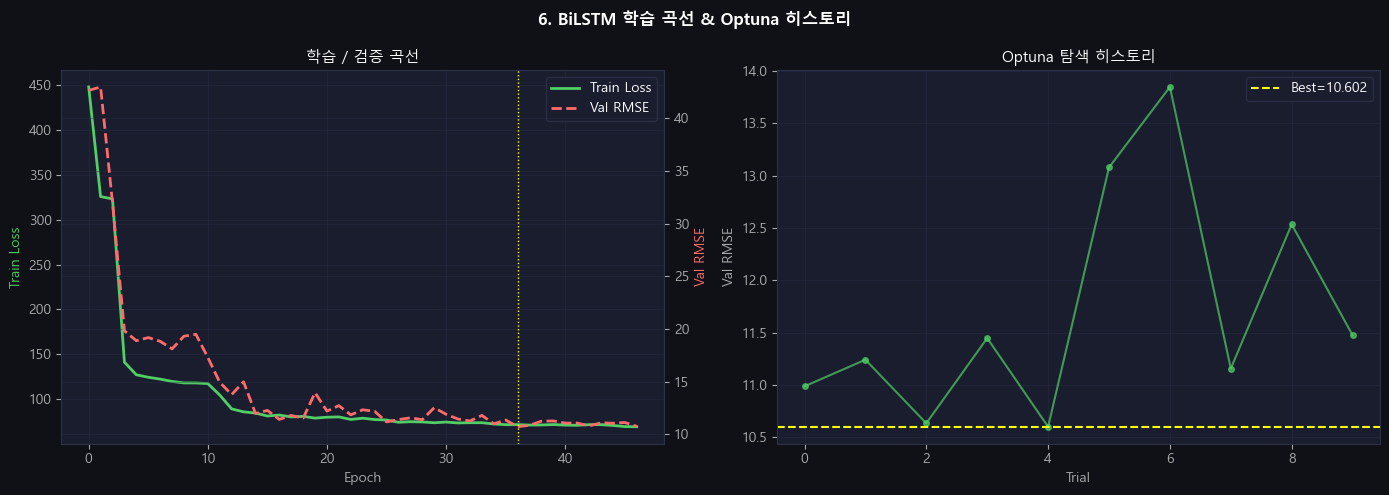


[BiLSTM] 완료 (2128초) | Val RMSE=10.715 | Val NASA(eval)=20.6 | Test NASA=5724.3 | Params=958,529


In [12]:
print('=== 6. BiLSTM 학습 (Optuna) ===')

best_bilstm_state = {'val': float('inf'), 'state': None, 'params': None}

def bilstm_objective(trial):
    hidden = trial.suggest_categorical('hidden_size', [64, 128, 256])
    layers = trial.suggest_int('num_layers', 1, 3)
    drop   = trial.suggest_float('dropout', 0.1, 0.5)
    fc     = trial.suggest_categorical('fc_size', [32, 64, 128])
    lr     = trial.suggest_float('lr', 1e-4, 1e-2, log=True)
    wd     = trial.suggest_float('weight_decay', 1e-6, 1e-3, log=True)

    set_seed(RANDOM_STATE + trial.number)
    model = BiLSTMModel(N_FEATURES, hidden, layers, drop, fc).to(DEVICE)
    opt   = optim.Adam(model.parameters(), lr=lr, weight_decay=wd)
    sch   = optim.lr_scheduler.ReduceLROnPlateau(opt, patience=5, factor=0.5)
    _, val_rmse, _ = train_model(model, tr_loader, va_loader, opt, sch, EPOCHS_SEARCH)

    if val_rmse < best_bilstm_state['val']:
        best_bilstm_state.update({'val': val_rmse, 'state': deepcopy(model.state_dict()),
                                   'params': trial.params})
    return val_rmse

study_bilstm = optuna.create_study(direction='minimize', sampler=TPESampler(seed=RANDOM_STATE))
study_bilstm.optimize(bilstm_objective, n_trials=N_TRIALS, show_progress_bar=True)
best_p = study_bilstm.best_params
print(f'\n최적 파라미터: {best_p}')

# 최종 학습
set_seed(RANDOM_STATE)
bilstm_model = BiLSTMModel(N_FEATURES,
                            best_p['hidden_size'], best_p['num_layers'],
                            best_p['dropout'],     best_p['fc_size']).to(DEVICE)
opt_final = optim.Adam(bilstm_model.parameters(),
                        lr=best_p['lr'], weight_decay=best_p['weight_decay'])
sch_final = optim.lr_scheduler.ReduceLROnPlateau(opt_final, patience=7, factor=0.5)

t0 = time.time()
hist_bilstm, _, best_ep_bilstm = train_model(
    bilstm_model, tr_loader, va_loader, opt_final, sch_final, EPOCHS_FINAL, verbose=True)
elapsed_bilstm = time.time() - t0

val_pred_bilstm      = predict_np(bilstm_model, X_val)
val_eval_pred_bilstm = predict_np(bilstm_model, X_val_eval)
test_pred_bilstm     = predict_np(bilstm_model, X_test)

val_metrics_bilstm   = get_metrics(y_val,     val_pred_bilstm)
val_eval_nasa_bilstm = nasa_score(y_val_eval, val_eval_pred_bilstm)
test_metrics_bilstm  = get_metrics(y_test,    test_pred_bilstm)
n_params_bilstm = sum(p.numel() for p in bilstm_model.parameters())

ALL_RESULTS['BiLSTM'] = {
    'model': bilstm_model, 'params': best_p, 'history': hist_bilstm,
    'best_epoch': best_ep_bilstm, 'val_metrics': val_metrics_bilstm,
    'val_eval_nasa': val_eval_nasa_bilstm, 'test_metrics': test_metrics_bilstm,
    'fit_seconds': elapsed_bilstm, 'n_params': n_params_bilstm, 'study': study_bilstm,
}
BEST_MODELS['BiLSTM'] = bilstm_model

with mlflow.start_run(run_name='BiLSTM', nested=True):
    mlflow.set_tags({'model_family': 'rnn', 'model_name': 'BiLSTM'})
    mlflow.log_params({**best_p, 'n_params': n_params_bilstm,
                       'best_epoch': best_ep_bilstm, 'fit_seconds': round(elapsed_bilstm,1)})
    mlflow.log_metrics({
        'val_rmse': val_metrics_bilstm['RMSE'], 'val_mae': val_metrics_bilstm['MAE'],
        'val_r2': val_metrics_bilstm['R2'],     'val_nasa': val_metrics_bilstm['NASA_Score'],
        'val_eval_nasa': val_eval_nasa_bilstm,
        'test_rmse': test_metrics_bilstm['RMSE'],'test_mae': test_metrics_bilstm['MAE'],
        'test_r2': test_metrics_bilstm['R2'],    'test_nasa': test_metrics_bilstm['NASA_Score'],
    })
    torch.save(bilstm_model.state_dict(), os.path.join(MODEL_DIR, 'BiLSTM_best.pt'))
    mlflow.log_artifact(os.path.join(MODEL_DIR, 'BiLSTM_best.pt'))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('6. BiLSTM 학습 곡선 & Optuna 히스토리', fontsize=12, fontweight='bold')
axes[0].plot(hist_bilstm['train_loss'], color=C[2], lw=2, label='Train Loss')
ax2 = axes[0].twinx()
ax2.plot(hist_bilstm['val_rmse'], color=C[1], lw=2, ls='--', label='Val RMSE')
ax2.axvline(best_ep_bilstm-1, color='yellow', lw=1, ls=':')
axes[0].set_facecolor(BG2)
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Train Loss', color=C[2])
ax2.set_ylabel('Val RMSE', color=C[1]); axes[0].set_title('학습 / 검증 곡선')
lines1,l1 = axes[0].get_legend_handles_labels(); lines2,l2 = ax2.get_legend_handles_labels()
axes[0].legend(lines1+lines2, l1+l2, loc='upper right')

trial_vals = [t.value for t in study_bilstm.trials if t.value is not None]
axes[1].plot(trial_vals, 'o-', color=C[2], alpha=0.7, ms=4)
axes[1].axhline(study_bilstm.best_value, color='yellow', lw=1.5, ls='--',
                label=f'Best={study_bilstm.best_value:.3f}')
axes[1].set_xlabel('Trial'); axes[1].set_ylabel('Val RMSE')
axes[1].set_title('Optuna 탐색 히스토리'); axes[1].legend(); axes[1].set_facecolor(BG2)
plt.tight_layout(); plt.show()

print(f'\n[BiLSTM] 완료 ({elapsed_bilstm:.0f}초) | '
      f'Val RMSE={val_metrics_bilstm["RMSE"]:.3f} | '
      f'Val NASA(eval)={val_eval_nasa_bilstm:.1f} | '
      f'Test NASA={test_metrics_bilstm["NASA_Score"]:.1f} | '
      f'Params={n_params_bilstm:,}')


## 7. Transformer 학습 (Optuna + MLflow)

**탐색 공간:**

| 파라미터 | 범위 |
|----------|------|
| `d_model` | 64, 128 (nhead와 정합 보장) |
| `nhead` | 2, 4, 8 |
| `num_layers` | 1 ~ 4 |
| `dim_feedforward` | 64, 128, 256 |
| `dropout` | 0.1 ~ 0.4 |

Pre-LN (norm_first=True) + GELU + ADAM


=== 7. Transformer 학습 (Optuna) ===


  0%|          | 0/10 [00:00<?, ?it/s]


최적 파라미터: {'d_model': 64, 'nhead': 8, 'num_layers': 4, 'dim_feedforward': 128, 'dropout': 0.15597101766581076, 'lr': 0.006097025297491433, 'weight_decay': 4.149795789891592e-05}
  Epoch  10 | Loss=72.9181 | Val RMSE=12.4679
  Epoch  20 | Loss=65.0946 | Val RMSE=12.2940
  Epoch  30 | Loss=60.7568 | Val RMSE=12.2300
  Epoch  40 | Loss=57.1786 | Val RMSE=11.6224


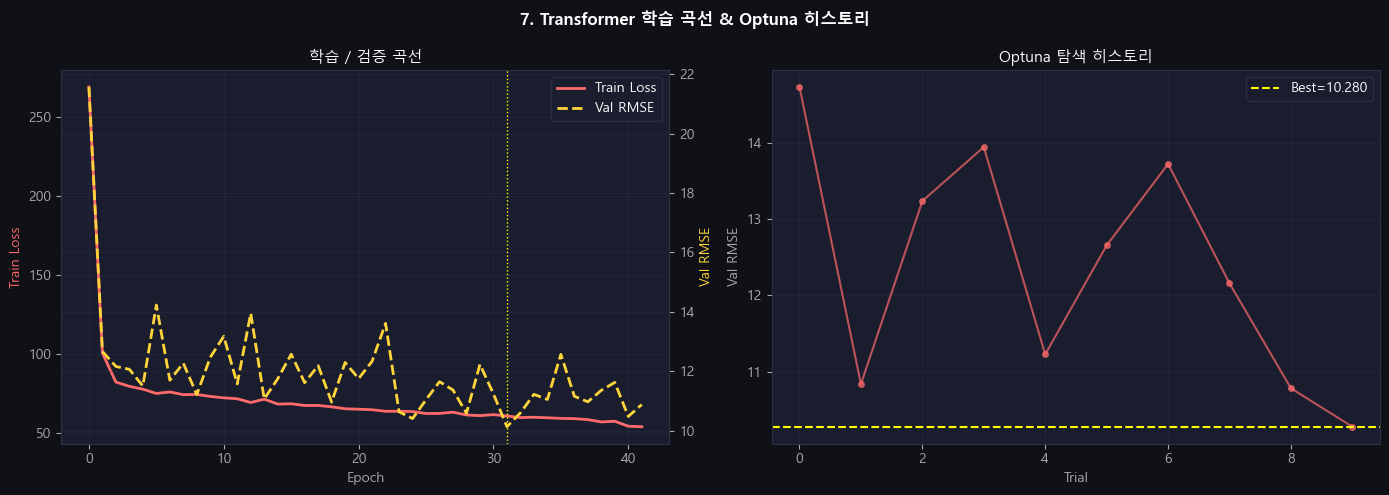


[Transformer] 완료 (1093초) | Val RMSE=10.131 | Val NASA(eval)=55.2 | Test NASA=6068.1 | Params=137,857


In [13]:
print('=== 7. Transformer 학습 (Optuna) ===')

best_tf_state = {'val': float('inf'), 'state': None, 'params': None}

def tf_objective(trial):
    d_model = trial.suggest_categorical('d_model', [64, 128])
    nhead   = trial.suggest_categorical('nhead', [2, 4, 8])
    if d_model % nhead != 0:   # 정합 불가 시 조기 종료
        return float('inf')
    layers  = trial.suggest_int('num_layers', 1, 4)
    dim_ff  = trial.suggest_categorical('dim_feedforward', [64, 128, 256])
    drop    = trial.suggest_float('dropout', 0.1, 0.4)
    lr      = trial.suggest_float('lr', 1e-4, 1e-2, log=True)
    wd      = trial.suggest_float('weight_decay', 1e-6, 1e-3, log=True)

    set_seed(RANDOM_STATE + trial.number)
    model = TransformerModel(N_FEATURES, d_model, nhead, layers, dim_ff, drop).to(DEVICE)
    opt   = optim.Adam(model.parameters(), lr=lr, weight_decay=wd)
    sch   = optim.lr_scheduler.ReduceLROnPlateau(opt, patience=5, factor=0.5)
    _, val_rmse, _ = train_model(model, tr_loader, va_loader, opt, sch, EPOCHS_SEARCH)

    if val_rmse < best_tf_state['val']:
        best_tf_state.update({'val': val_rmse, 'state': deepcopy(model.state_dict()),
                               'params': trial.params})
    return val_rmse

study_tf = optuna.create_study(direction='minimize', sampler=TPESampler(seed=RANDOM_STATE))
study_tf.optimize(tf_objective, n_trials=N_TRIALS, show_progress_bar=True)
best_p = {k: v for k, v in study_tf.best_params.items()}
print(f'\n최적 파라미터: {best_p}')

# 최종 학습
set_seed(RANDOM_STATE)
tf_model = TransformerModel(N_FEATURES,
                             best_p['d_model'], best_p['nhead'], best_p['num_layers'],
                             best_p['dim_feedforward'], best_p['dropout']).to(DEVICE)
opt_final = optim.Adam(tf_model.parameters(),
                        lr=best_p['lr'], weight_decay=best_p['weight_decay'])
sch_final = optim.lr_scheduler.ReduceLROnPlateau(opt_final, patience=7, factor=0.5)

t0 = time.time()
hist_tf, _, best_ep_tf = train_model(
    tf_model, tr_loader, va_loader, opt_final, sch_final, EPOCHS_FINAL, verbose=True)
elapsed_tf = time.time() - t0

val_pred_tf      = predict_np(tf_model, X_val)
val_eval_pred_tf = predict_np(tf_model, X_val_eval)
test_pred_tf     = predict_np(tf_model, X_test)

val_metrics_tf   = get_metrics(y_val,     val_pred_tf)
val_eval_nasa_tf = nasa_score(y_val_eval, val_eval_pred_tf)
test_metrics_tf  = get_metrics(y_test,    test_pred_tf)
n_params_tf = sum(p.numel() for p in tf_model.parameters())

ALL_RESULTS['Transformer'] = {
    'model': tf_model, 'params': best_p, 'history': hist_tf,
    'best_epoch': best_ep_tf, 'val_metrics': val_metrics_tf,
    'val_eval_nasa': val_eval_nasa_tf, 'test_metrics': test_metrics_tf,
    'fit_seconds': elapsed_tf, 'n_params': n_params_tf, 'study': study_tf,
}
BEST_MODELS['Transformer'] = tf_model

with mlflow.start_run(run_name='Transformer', nested=True):
    mlflow.set_tags({'model_family': 'attention', 'model_name': 'Transformer'})
    mlflow.log_params({**best_p, 'n_params': n_params_tf,
                       'best_epoch': best_ep_tf, 'fit_seconds': round(elapsed_tf,1)})
    mlflow.log_metrics({
        'val_rmse': val_metrics_tf['RMSE'],   'val_mae': val_metrics_tf['MAE'],
        'val_r2': val_metrics_tf['R2'],       'val_nasa': val_metrics_tf['NASA_Score'],
        'val_eval_nasa': val_eval_nasa_tf,
        'test_rmse': test_metrics_tf['RMSE'], 'test_mae': test_metrics_tf['MAE'],
        'test_r2': test_metrics_tf['R2'],     'test_nasa': test_metrics_tf['NASA_Score'],
    })
    torch.save(tf_model.state_dict(), os.path.join(MODEL_DIR, 'Transformer_best.pt'))
    mlflow.log_artifact(os.path.join(MODEL_DIR, 'Transformer_best.pt'))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('7. Transformer 학습 곡선 & Optuna 히스토리', fontsize=12, fontweight='bold')
axes[0].plot(hist_tf['train_loss'], color=C[1], lw=2, label='Train Loss')
ax2 = axes[0].twinx()
ax2.plot(hist_tf['val_rmse'], color=C[3], lw=2, ls='--', label='Val RMSE')
ax2.axvline(best_ep_tf-1, color='yellow', lw=1, ls=':')
axes[0].set_facecolor(BG2)
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Train Loss', color=C[1])
ax2.set_ylabel('Val RMSE', color=C[3]); axes[0].set_title('학습 / 검증 곡선')
lines1,l1 = axes[0].get_legend_handles_labels(); lines2,l2 = ax2.get_legend_handles_labels()
axes[0].legend(lines1+lines2, l1+l2, loc='upper right')

trial_vals = [t.value for t in study_tf.trials if t.value is not None]
axes[1].plot([v for v in trial_vals if v < float('inf')], 'o-', color=C[1], alpha=0.7, ms=4)
axes[1].axhline(study_tf.best_value, color='yellow', lw=1.5, ls='--',
                label=f'Best={study_tf.best_value:.3f}')
axes[1].set_xlabel('Trial'); axes[1].set_ylabel('Val RMSE')
axes[1].set_title('Optuna 탐색 히스토리'); axes[1].legend(); axes[1].set_facecolor(BG2)
plt.tight_layout(); plt.show()

print(f'\n[Transformer] 완료 ({elapsed_tf:.0f}초) | '
      f'Val RMSE={val_metrics_tf["RMSE"]:.3f} | '
      f'Val NASA(eval)={val_eval_nasa_tf:.1f} | '
      f'Test NASA={test_metrics_tf["NASA_Score"]:.1f} | '
      f'Params={n_params_tf:,}')


## 8. CNN+Transformer 학습 (Optuna + MLflow)

**탐색 공간:**

| 파라미터 | 범위 |
|----------|------|
| `cnn_channels` | 32, 64, 128 |
| `kernel_size` | 3, 5, 7 |
| `d_model` | 64, 128 |
| `nhead` | 2, 4, 8 |
| `num_layers` | 1 ~ 3 |
| `dropout` | 0.1 ~ 0.4 |

CNN이 지역 시계열 패턴을 추출하고, Transformer가 전역 시간 의존성을 학습


=== 8. CNN+Transformer 학습 (Optuna) ===


  0%|          | 0/10 [00:00<?, ?it/s]


최적 파라미터: {'cnn_channels': 128, 'kernel_size': 7, 'd_model': 128, 'nhead': 8, 'num_layers': 3, 'dropout': 0.15597101766581076, 'lr': 0.006097025297491433, 'weight_decay': 4.149795789891592e-05}
  Epoch  10 | Loss=65.1483 | Val RMSE=15.9748


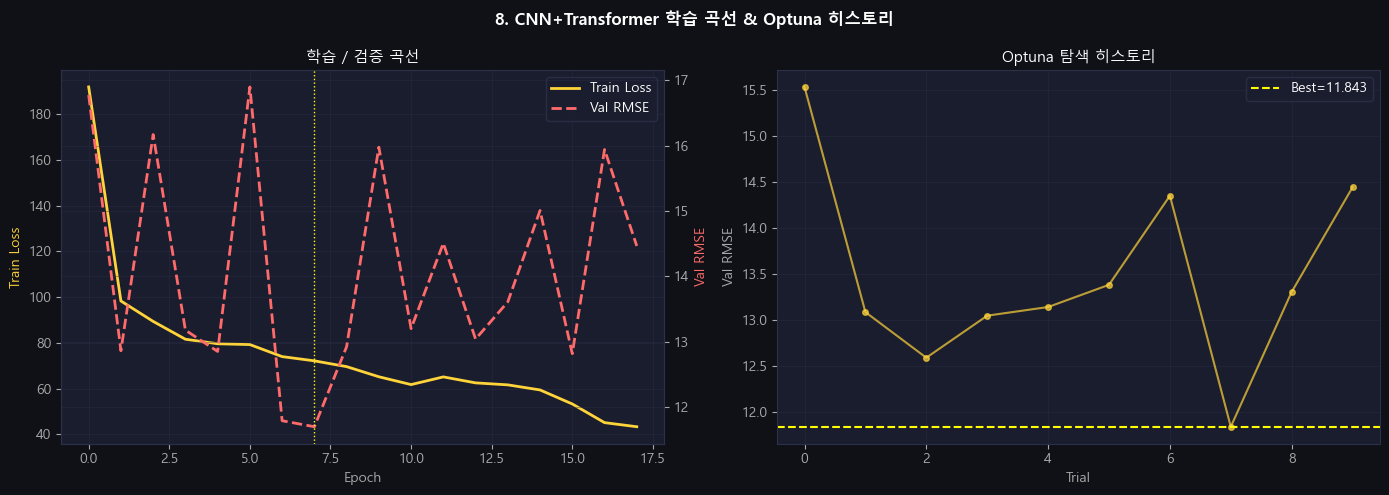


[CNN+Transformer] 완료 (538초) | Val RMSE=11.705 | Val NASA(eval)=67.1 | Test NASA=9480.7 | Params=544,513


In [14]:
print('=== 8. CNN+Transformer 학습 (Optuna) ===')

best_cnntf_state = {'val': float('inf'), 'state': None, 'params': None}

def cnntf_objective(trial):
    cnn_ch  = trial.suggest_categorical('cnn_channels', [32, 64, 128])
    k_size  = trial.suggest_categorical('kernel_size', [3, 5, 7])
    d_model = trial.suggest_categorical('d_model', [64, 128])
    nhead   = trial.suggest_categorical('nhead', [2, 4, 8])
    if d_model % nhead != 0:
        return float('inf')
    layers  = trial.suggest_int('num_layers', 1, 3)
    drop    = trial.suggest_float('dropout', 0.1, 0.4)
    lr      = trial.suggest_float('lr', 1e-4, 1e-2, log=True)
    wd      = trial.suggest_float('weight_decay', 1e-6, 1e-3, log=True)

    set_seed(RANDOM_STATE + trial.number)
    model = CNNTransformerModel(N_FEATURES, cnn_ch, k_size, d_model, nhead, layers, drop).to(DEVICE)
    opt   = optim.Adam(model.parameters(), lr=lr, weight_decay=wd)
    sch   = optim.lr_scheduler.ReduceLROnPlateau(opt, patience=5, factor=0.5)
    _, val_rmse, _ = train_model(model, tr_loader, va_loader, opt, sch, EPOCHS_SEARCH)

    if val_rmse < best_cnntf_state['val']:
        best_cnntf_state.update({'val': val_rmse, 'state': deepcopy(model.state_dict()),
                                  'params': trial.params})
    return val_rmse

study_cnntf = optuna.create_study(direction='minimize', sampler=TPESampler(seed=RANDOM_STATE))
study_cnntf.optimize(cnntf_objective, n_trials=N_TRIALS, show_progress_bar=True)
best_p = {k: v for k, v in study_cnntf.best_params.items()}
print(f'\n최적 파라미터: {best_p}')

# 최종 학습
set_seed(RANDOM_STATE)
cnntf_model = CNNTransformerModel(
    N_FEATURES, best_p['cnn_channels'], best_p['kernel_size'],
    best_p['d_model'], best_p['nhead'], best_p['num_layers'], best_p['dropout']
).to(DEVICE)
opt_final = optim.Adam(cnntf_model.parameters(),
                        lr=best_p['lr'], weight_decay=best_p['weight_decay'])
sch_final = optim.lr_scheduler.ReduceLROnPlateau(opt_final, patience=7, factor=0.5)

t0 = time.time()
hist_cnntf, _, best_ep_cnntf = train_model(
    cnntf_model, tr_loader, va_loader, opt_final, sch_final, EPOCHS_FINAL, verbose=True)
elapsed_cnntf = time.time() - t0

val_pred_cnntf      = predict_np(cnntf_model, X_val)
val_eval_pred_cnntf = predict_np(cnntf_model, X_val_eval)
test_pred_cnntf     = predict_np(cnntf_model, X_test)

val_metrics_cnntf   = get_metrics(y_val,     val_pred_cnntf)
val_eval_nasa_cnntf = nasa_score(y_val_eval, val_eval_pred_cnntf)
test_metrics_cnntf  = get_metrics(y_test,    test_pred_cnntf)
n_params_cnntf = sum(p.numel() for p in cnntf_model.parameters())

ALL_RESULTS['CNN+Transformer'] = {
    'model': cnntf_model, 'params': best_p, 'history': hist_cnntf,
    'best_epoch': best_ep_cnntf, 'val_metrics': val_metrics_cnntf,
    'val_eval_nasa': val_eval_nasa_cnntf, 'test_metrics': test_metrics_cnntf,
    'fit_seconds': elapsed_cnntf, 'n_params': n_params_cnntf, 'study': study_cnntf,
}
BEST_MODELS['CNN+Transformer'] = cnntf_model

with mlflow.start_run(run_name='CNN+Transformer', nested=True):
    mlflow.set_tags({'model_family': 'hybrid', 'model_name': 'CNN+Transformer'})
    mlflow.log_params({**best_p, 'n_params': n_params_cnntf,
                       'best_epoch': best_ep_cnntf, 'fit_seconds': round(elapsed_cnntf,1)})
    mlflow.log_metrics({
        'val_rmse': val_metrics_cnntf['RMSE'],  'val_mae': val_metrics_cnntf['MAE'],
        'val_r2': val_metrics_cnntf['R2'],      'val_nasa': val_metrics_cnntf['NASA_Score'],
        'val_eval_nasa': val_eval_nasa_cnntf,
        'test_rmse': test_metrics_cnntf['RMSE'],'test_mae': test_metrics_cnntf['MAE'],
        'test_r2': test_metrics_cnntf['R2'],    'test_nasa': test_metrics_cnntf['NASA_Score'],
    })
    torch.save(cnntf_model.state_dict(), os.path.join(MODEL_DIR, 'CNN+Transformer_best.pt'))
    mlflow.log_artifact(os.path.join(MODEL_DIR, 'CNN+Transformer_best.pt'))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('8. CNN+Transformer 학습 곡선 & Optuna 히스토리', fontsize=12, fontweight='bold')
axes[0].plot(hist_cnntf['train_loss'], color=C[3], lw=2, label='Train Loss')
ax2 = axes[0].twinx()
ax2.plot(hist_cnntf['val_rmse'], color=C[1], lw=2, ls='--', label='Val RMSE')
ax2.axvline(best_ep_cnntf-1, color='yellow', lw=1, ls=':')
axes[0].set_facecolor(BG2)
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Train Loss', color=C[3])
ax2.set_ylabel('Val RMSE', color=C[1]); axes[0].set_title('학습 / 검증 곡선')
lines1,l1 = axes[0].get_legend_handles_labels(); lines2,l2 = ax2.get_legend_handles_labels()
axes[0].legend(lines1+lines2, l1+l2, loc='upper right')

trial_vals = [t.value for t in study_cnntf.trials if t.value is not None]
axes[1].plot([v for v in trial_vals if v < float('inf')], 'o-', color=C[3], alpha=0.7, ms=4)
axes[1].axhline(study_cnntf.best_value, color='yellow', lw=1.5, ls='--',
                label=f'Best={study_cnntf.best_value:.3f}')
axes[1].set_xlabel('Trial'); axes[1].set_ylabel('Val RMSE')
axes[1].set_title('Optuna 탐색 히스토리'); axes[1].legend(); axes[1].set_facecolor(BG2)
plt.tight_layout(); plt.show()

print(f'\n[CNN+Transformer] 완료 ({elapsed_cnntf:.0f}초) | '
      f'Val RMSE={val_metrics_cnntf["RMSE"]:.3f} | '
      f'Val NASA(eval)={val_eval_nasa_cnntf:.1f} | '
      f'Test NASA={test_metrics_cnntf["NASA_Score"]:.1f} | '
      f'Params={n_params_cnntf:,}')


## 9. 모델 성능 비교

> **모델 선택 기준은 Test가 아님** — Validation/NASA(eval) 중심 정렬  
> Test는 최종 일반화 성능 확인용


=== 9. 모델 성능 비교 ===


,선정순위,모델,파라미터 수,Best Epoch,Val RMSE,Val MAE,Val R²,Val NASA(eval),Test RMSE,Test MAE,Test R²,Test NASA,학습시간(초)
0,1,BiLSTM,"958,529",37,10.715000,7.594000,0.933700,20.6,25.684000,18.247000,0.771900,5724.3,2128.000000
1,2,LSTM,"27,777",27,10.533000,7.634000,0.936000,30.1,28.415000,20.036000,0.720800,17670.9,78.200000
2,3,Transformer,"137,857",32,10.131000,6.964000,0.940800,55.2,26.127000,18.435000,0.764000,6068.1,1092.900000
3,4,CNN+Transformer,"544,513",8,11.705000,8.479000,0.920900,67.1,27.199000,19.502000,0.744200,9480.7,538.300000



🏆 최고 모델 (Val NASA(eval) 기준): BiLSTM
   Val RMSE=10.715 | Val NASA(eval)=20.6 | Test RMSE=25.684 | Test NASA=5724.3
📄 성능표 저장: results_dl\model_comparison_dl.csv


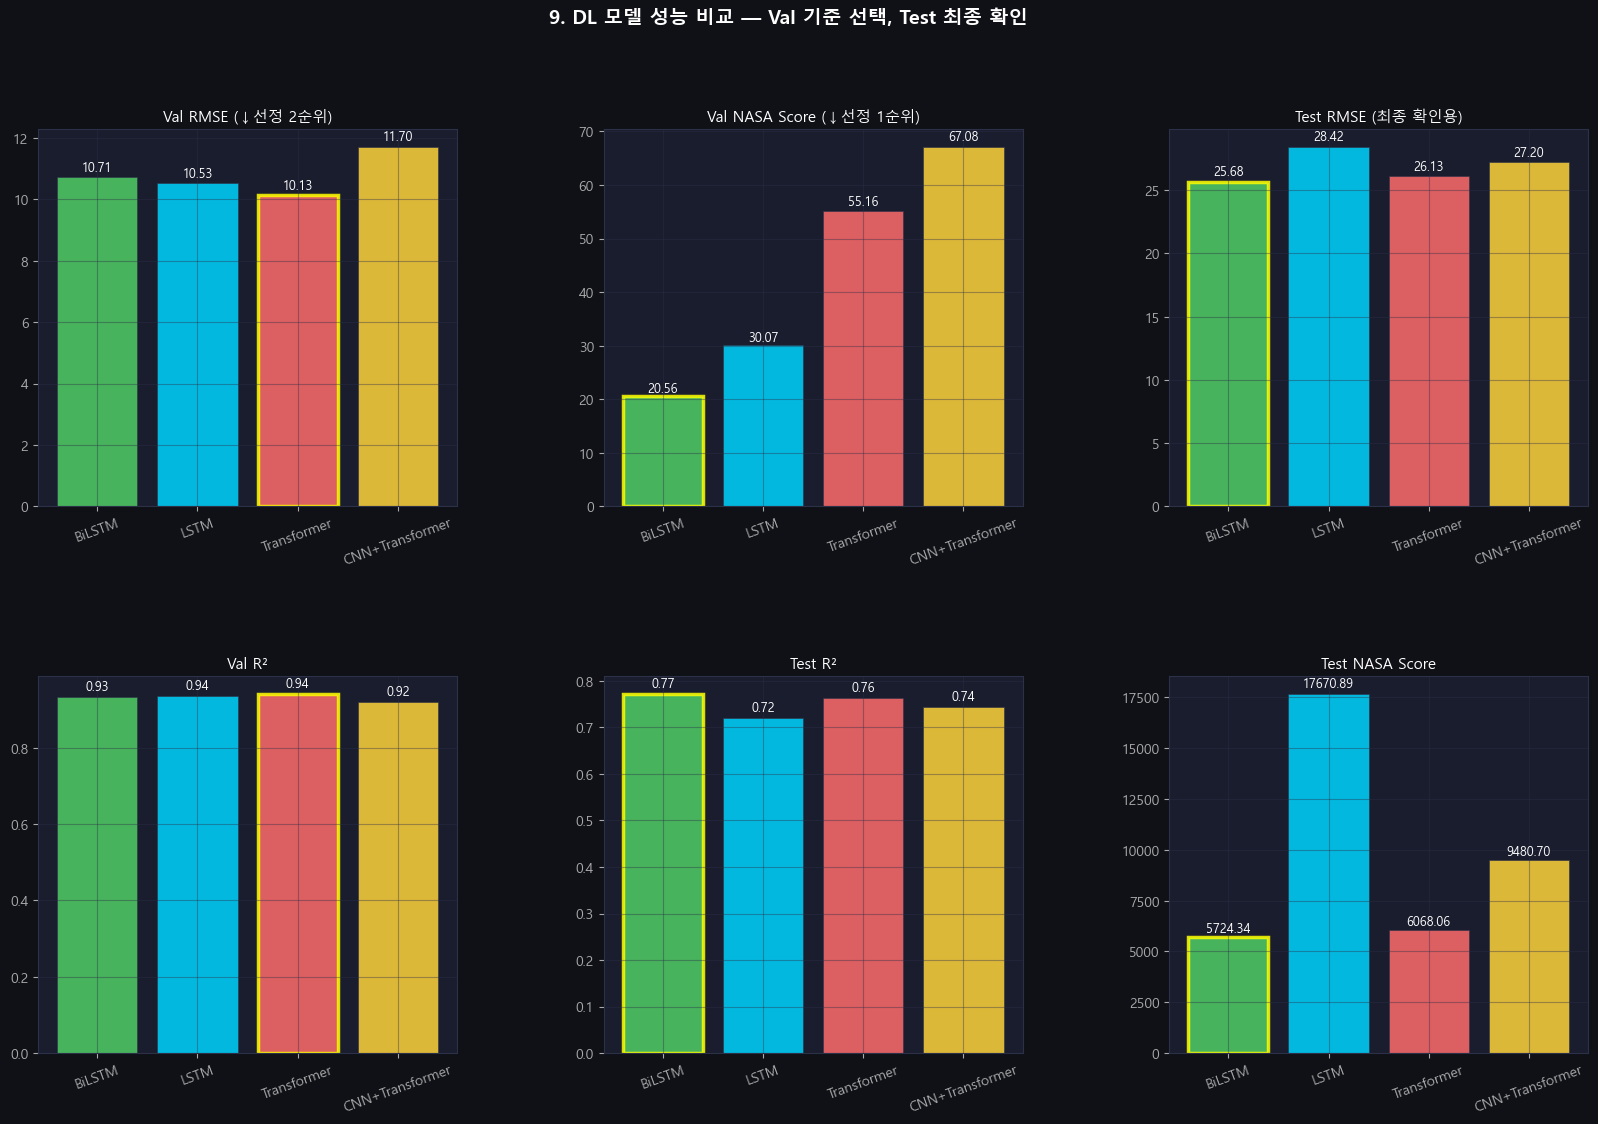

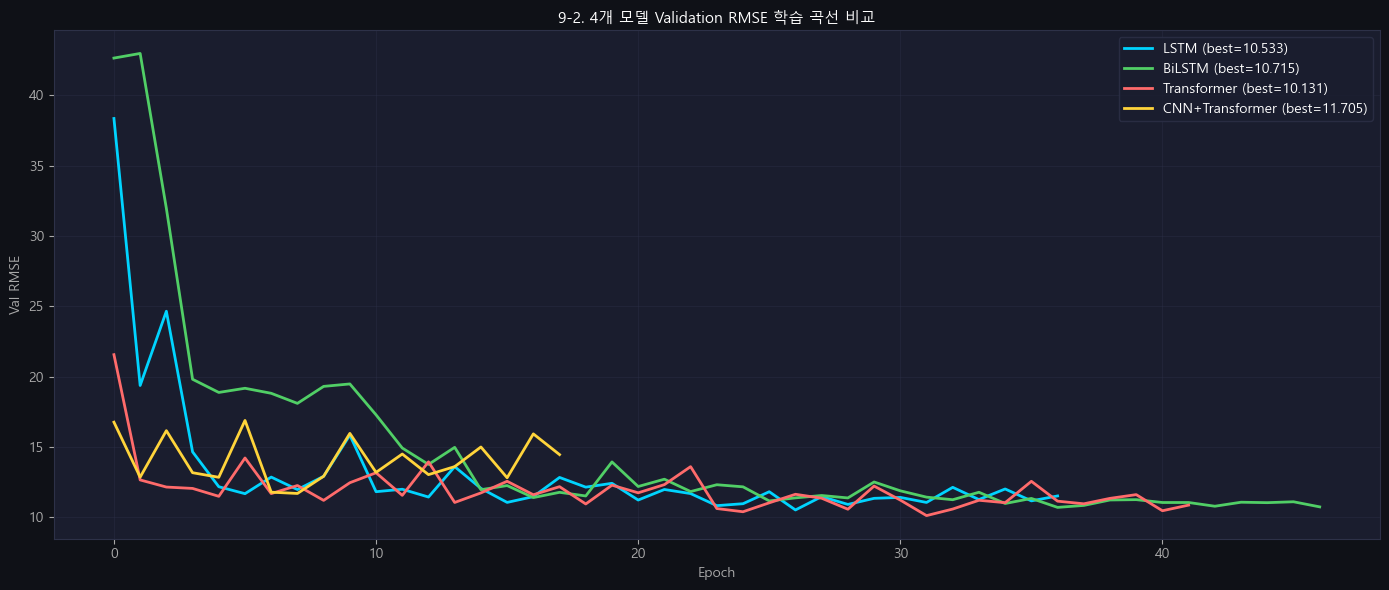

In [16]:
print('=== 9. 모델 성능 비교 ===')
import matplotlib.gridspec as gridspec

rows = []
for mname, res in ALL_RESULTS.items():
    rows.append({
        '모델'           : mname,
        '파라미터 수'    : f'{res["n_params"]:,}',
        'Best Epoch'     : res['best_epoch'],
        'Val RMSE'       : round(res['val_metrics']['RMSE'], 3),
        'Val MAE'        : round(res['val_metrics']['MAE'],  3),
        'Val R²'         : round(res['val_metrics']['R2'],   4),
        'Val NASA(eval)' : round(res['val_eval_nasa'],       1),
        'Test RMSE'      : round(res['test_metrics']['RMSE'],3),
        'Test MAE'       : round(res['test_metrics']['MAE'], 3),
        'Test R²'        : round(res['test_metrics']['R2'],  4),
        'Test NASA'      : round(res['test_metrics']['NASA_Score'], 1),
        '학습시간(초)'   : round(res['fit_seconds'], 1),
    })

result_df = pd.DataFrame(rows)
result_df = result_df.sort_values('Val NASA(eval)').reset_index(drop=True)
result_df['선정순위'] = np.arange(1, len(result_df) + 1)

display_cols = ['선정순위','모델','파라미터 수','Best Epoch',
                'Val RMSE','Val MAE','Val R²','Val NASA(eval)',
                'Test RMSE','Test MAE','Test R²','Test NASA','학습시간(초)']
display(result_df[display_cols]
        .style
        .background_gradient(subset=['Val NASA(eval)','Val RMSE','Test NASA','Test RMSE'],
                             cmap='RdYlGn_r')
        .background_gradient(subset=['Val R²','Test R²'], cmap='RdYlGn')
        .format({c: '{:.3f}' for c in ['Val RMSE','Val MAE','Val R²',
                                        'Test RMSE','Test MAE','Test R²']})
        .format({'Val NASA(eval)': '{:.1f}', 'Test NASA': '{:.1f}'}))

best_model_name = result_df.iloc[0]['모델']
best_res = ALL_RESULTS[best_model_name]
print(f'\n🏆 최고 모델 (Val NASA(eval) 기준): {best_model_name}')
print(f'   Val RMSE={best_res["val_metrics"]["RMSE"]:.3f} | '
      f'Val NASA(eval)={best_res["val_eval_nasa"]:.1f} | '
      f'Test RMSE={best_res["test_metrics"]["RMSE"]:.3f} | '
      f'Test NASA={best_res["test_metrics"]["NASA_Score"]:.1f}')

result_csv_path = os.path.join(RESULT_DIR, 'model_comparison_dl.csv')
result_df[display_cols].to_csv(result_csv_path, index=False, encoding='utf-8-sig')
print(f'📄 성능표 저장: {result_csv_path}')

# ── 6-지표 비교 막대 그래프 ─────────────────────────────────────────────────
model_names   = [r['모델'] for _, r in result_df.iterrows()]
colors_bar    = [MODEL_COLORS[m] for m in model_names]

metrics_cfg = [
    ('Val RMSE',        'val_metrics.RMSE',         True,  'Val RMSE (↓선정 2순위)'),
    ('Val NASA(eval)',  'val_eval_nasa',             True,  'Val NASA Score (↓선정 1순위)'),
    ('Test RMSE',       'test_metrics.RMSE',         True,  'Test RMSE (최종 확인용)'),
    ('Val R²',          'val_metrics.R2',            False, 'Val R²'),
    ('Test R²',         'test_metrics.R2',           False, 'Test R²'),
    ('Test NASA',       'test_metrics.NASA_Score',   True,  'Test NASA Score'),
]

def get_val(res, key):
    if '.' in key:
        a, b = key.split('.'); return res[a][b]
    return res[key]

fig = plt.figure(figsize=(20, 12), facecolor=BG)
fig.suptitle('9. DL 모델 성능 비교 — Val 기준 선택, Test 최종 확인', fontsize=14, fontweight='bold')
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

for idx, (_, key, lower_better, title) in enumerate(metrics_cfg):
    ax = fig.add_subplot(gs[idx // 3, idx % 3])
    vals = [get_val(ALL_RESULTS[m], key) for m in model_names]
    bars = ax.bar(model_names, vals, color=colors_bar, alpha=0.85,
                  edgecolor=GRID, linewidth=0.5)
    best_i = np.argmin(vals) if lower_better else np.argmax(vals)
    bars[best_i].set_edgecolor('yellow'); bars[best_i].set_linewidth(2.5)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()*1.01,
                f'{v:.2f}', ha='center', va='bottom', fontsize=9, color=WHITE)
    ax.set_title(title); ax.tick_params(axis='x', rotation=20)
    ax.set_facecolor(BG2)

plt.tight_layout(); plt.show()

# ── 학습 곡선 4개 모델 비교 ──────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 6))
for mname, res in ALL_RESULTS.items():
    ax.plot(res['history']['val_rmse'], color=MODEL_COLORS[mname],
            lw=2, label=f'{mname} (best={res["val_metrics"]["RMSE"]:.3f})')
ax.set_title('9-2. 4개 모델 Validation RMSE 학습 곡선 비교')
ax.set_xlabel('Epoch'); ax.set_ylabel('Val RMSE')
ax.legend(); ax.set_facecolor(BG2)
plt.tight_layout(); plt.show()


## 10. Test 세트 상세 평가 — 엔진 100대 마지막 사이클

=== 10. Test 세트 상세 평가 ===


,unit_nr,actual_RUL,LSTM_pred,LSTM_err,BiLSTM_pred,BiLSTM_err,Transformer_pred,Transformer_err,CNN+Transformer_pred,CNN+Transformer_err
0,1,18,28.8,10.8,26.2,8.2,19.7,1.7,21.4,3.4
1,2,79,111.4,32.4,110.9,31.9,87.6,8.6,103.2,24.2
2,3,106,120.9,14.9,120.9,14.9,113.3,7.3,118.5,12.5
3,4,110,72.9,-37.1,80.4,-29.6,98.9,-11.1,72.7,-37.3
4,5,15,25.6,10.6,19.3,4.3,23.2,8.2,20.8,5.8
5,6,155,122.2,-32.8,119.0,-36.0,113.9,-41.1,122.1,-32.9
6,7,6,11.6,5.6,10.0,4.0,8.5,2.5,17.1,11.1
7,8,90,89.7,-0.3,86.1,-3.9,85.4,-4.6,84.3,-5.7
8,9,11,26.3,15.3,19.9,8.9,19.5,8.5,24.1,13.1
9,10,79,117.0,38.0,117.9,38.9,122.5,43.5,118.6,39.6


,평균 오차(bias),오차 표준편차,조기예측 비율,늦은예측 비율,|오차|≤10 비율,|오차|≤20 비율
모델,,,,,,
LSTM,-2.60,28.30,39.4%,60.6%,38.2%,64.1%
BiLSTM,-2.24,25.59,37.8%,62.2%,45.2%,66.0%
Transformer,-3.26,25.92,43.6%,56.4%,44.0%,66.0%
CNN+Transformer,-2.76,27.06,39.4%,60.6%,38.6%,64.5%


📄 엔진별 test 예측 저장: results_dl\test_engine_predictions_dl.csv


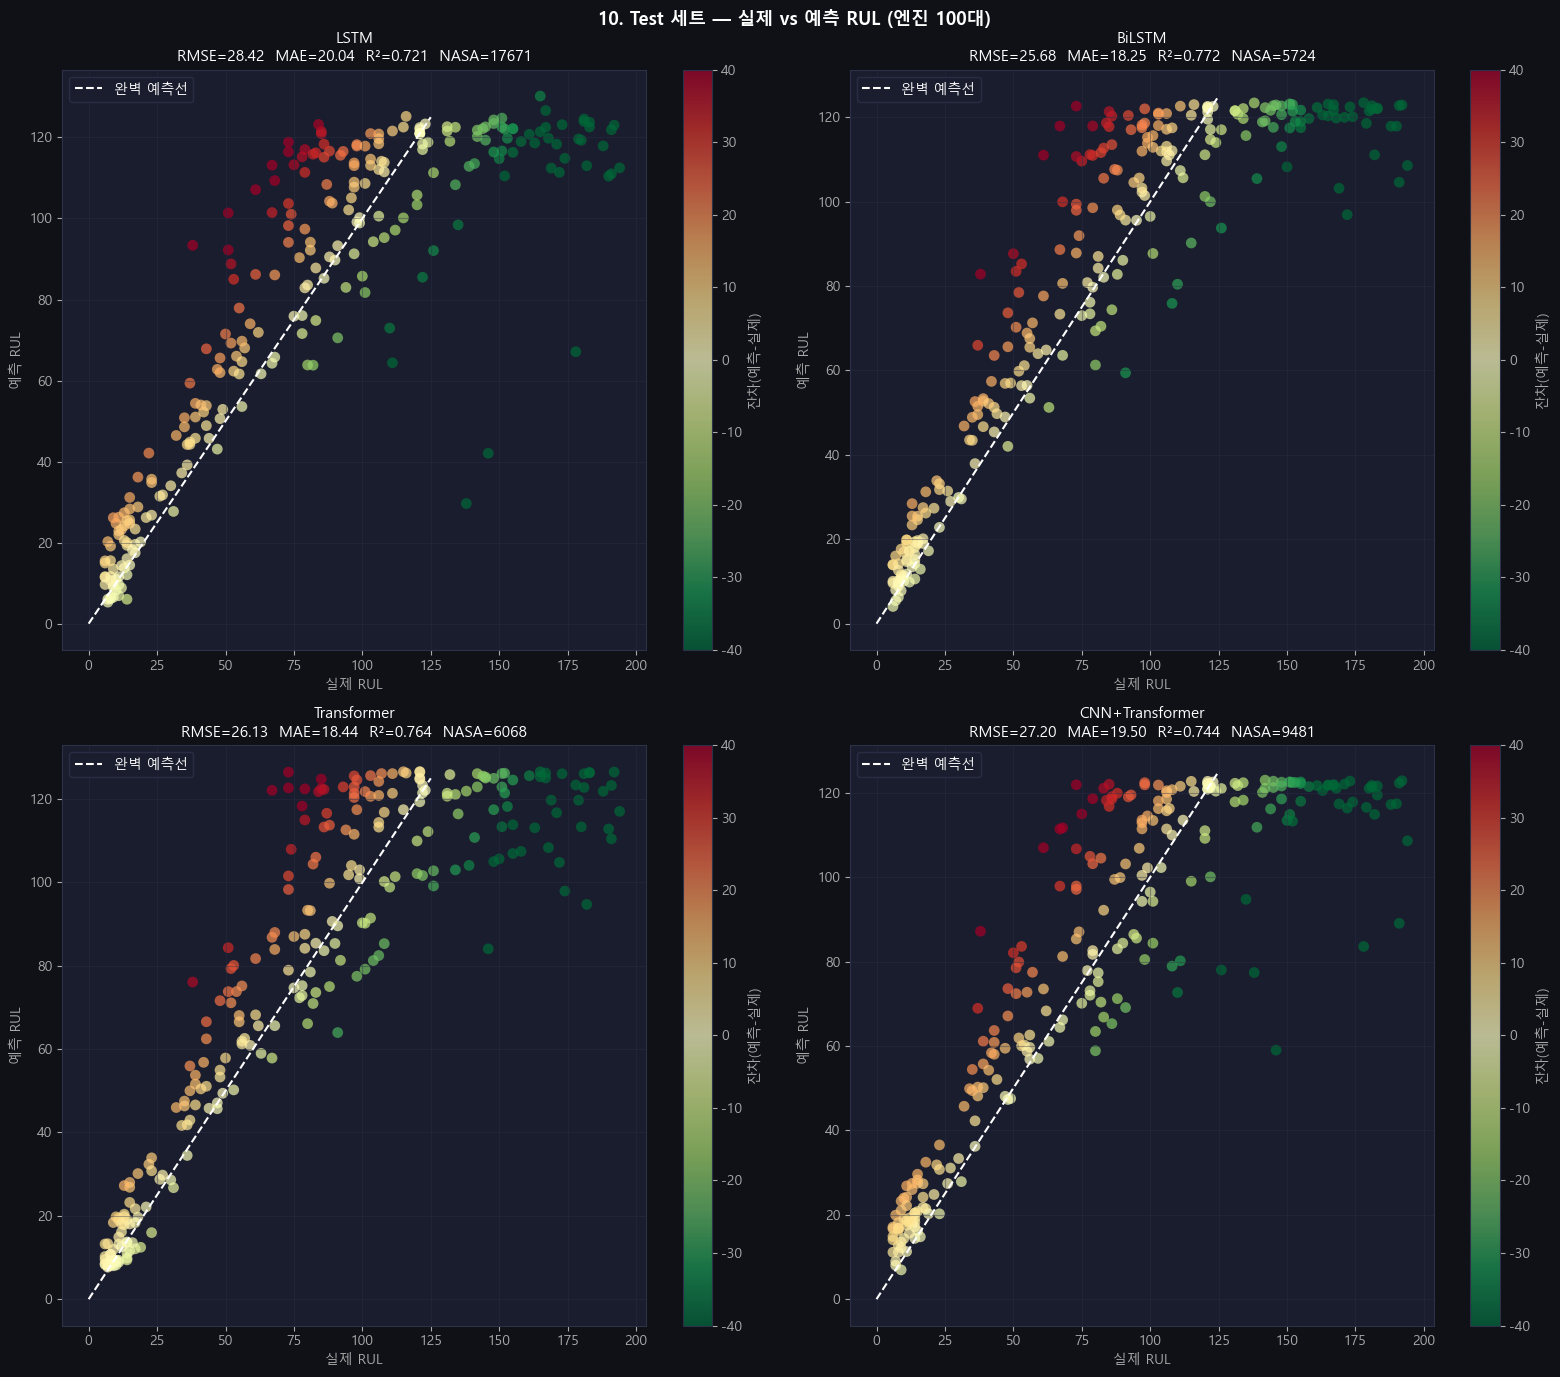

In [17]:
print('=== 10. Test 세트 상세 평가 ===')

test_pred_all = {m: clip_rul(predict_np(BEST_MODELS[m], X_test)) for m in MODEL_NAMES}

test_detail = pd.DataFrame({'unit_nr': np.arange(1, len(y_test)+1),
                             'actual_RUL': y_test.astype(int)})
for m, pred in test_pred_all.items():
    test_detail[f'{m}_pred'] = np.round(pred, 1)
    test_detail[f'{m}_err' ] = np.round(pred - y_test, 1)

display(test_detail.head(20))

# 오차 요약
err_rows = []
for mname, pred in test_pred_all.items():
    errs = pred - y_test
    err_rows.append({
        '모델'           : mname,
        '평균 오차(bias)': round(errs.mean(), 2),
        '오차 표준편차'  : round(errs.std(), 2),
        '조기예측 비율'  : f'{(errs < 0).mean()*100:.1f}%',
        '늦은예측 비율'  : f'{(errs > 0).mean()*100:.1f}%',
        '|오차|≤10 비율' : f'{(np.abs(errs) <= 10).mean()*100:.1f}%',
        '|오차|≤20 비율' : f'{(np.abs(errs) <= 20).mean()*100:.1f}%',
    })
err_df = pd.DataFrame(err_rows).set_index('모델')
display(err_df)

test_detail_path = os.path.join(RESULT_DIR, 'test_engine_predictions_dl.csv')
test_detail.to_csv(test_detail_path, index=False, encoding='utf-8-sig')
print(f'📄 엔진별 test 예측 저장: {test_detail_path}')

# 4개 모델 실제 vs 예측 scatter
fig, axes = plt.subplots(2, 2, figsize=(16, 14))
fig.suptitle('10. Test 세트 — 실제 vs 예측 RUL (엔진 100대)', fontsize=13, fontweight='bold')

for ax, mname in zip(axes.flat, MODEL_NAMES):
    pred = test_pred_all[mname]
    err  = pred - y_test
    sc   = ax.scatter(y_test, pred, c=err, cmap='RdYlGn_r', alpha=0.7, s=60,
                      vmin=-40, vmax=40, edgecolors='none')
    ax.plot([0, 125], [0, 125], color='white', lw=1.5, ls='--', label='완벽 예측선')
    m = get_metrics(y_test, pred)
    ax.set_title(f'{mname}\nRMSE={m["RMSE"]:.2f}  MAE={m["MAE"]:.2f}  '
                 f'R²={m["R2"]:.3f}  NASA={m["NASA_Score"]:.0f}')
    ax.set_xlabel('실제 RUL'); ax.set_ylabel('예측 RUL')
    ax.legend(loc='upper left'); ax.set_facecolor(BG2)
    plt.colorbar(sc, ax=ax, label='잔차(예측-실제)')

plt.tight_layout(); plt.show()


## 11. 잔차 분석 — Validation 구간별 오차 패턴

=== 11. 잔차 분석 ===


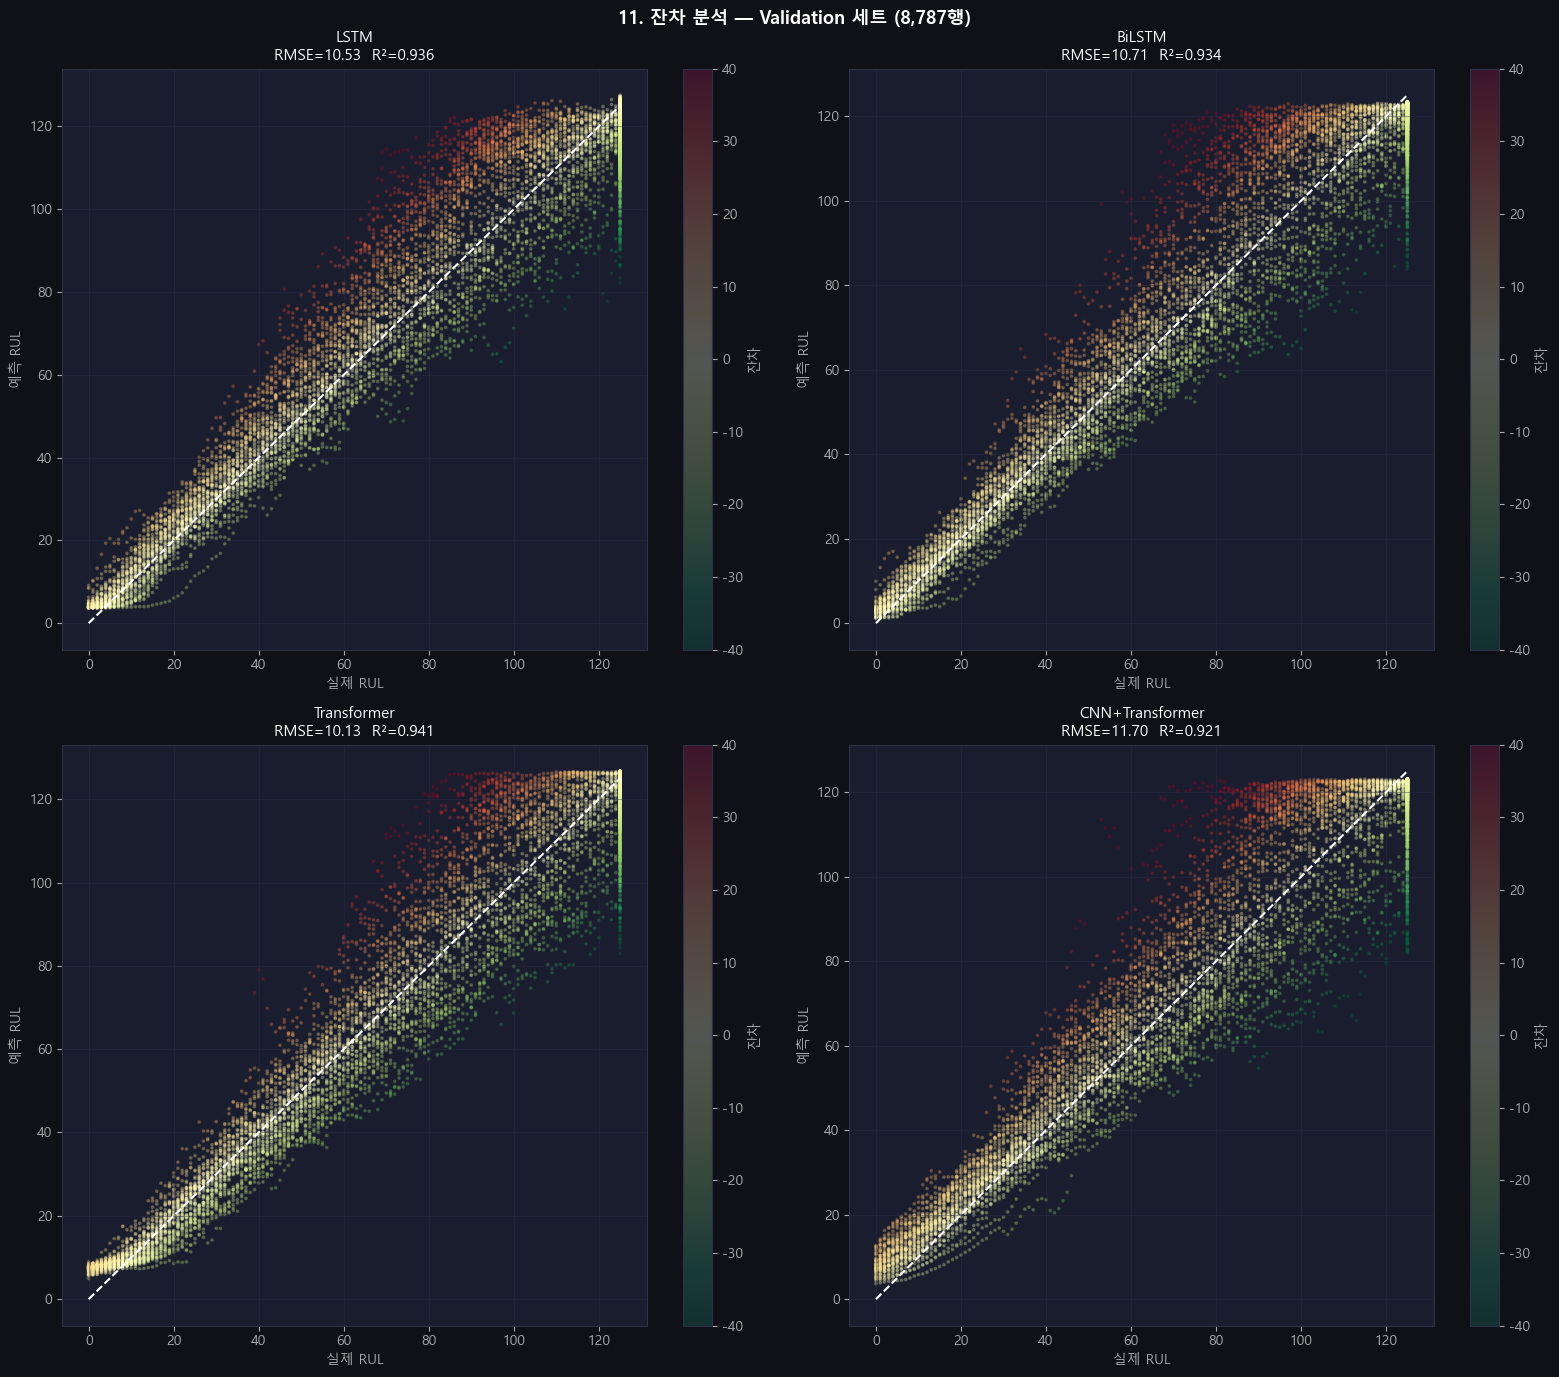

--- 구간별 MAE (Validation) ---


,말기(0~30),중기(31~80),초기(81~125)
모델,,,
LSTM,3.80,8.76,8.34
BiLSTM,3.29,8.71,8.48
Transformer,3.63,7.69,7.69
CNN+Transformer,5.39,9.28,9.08


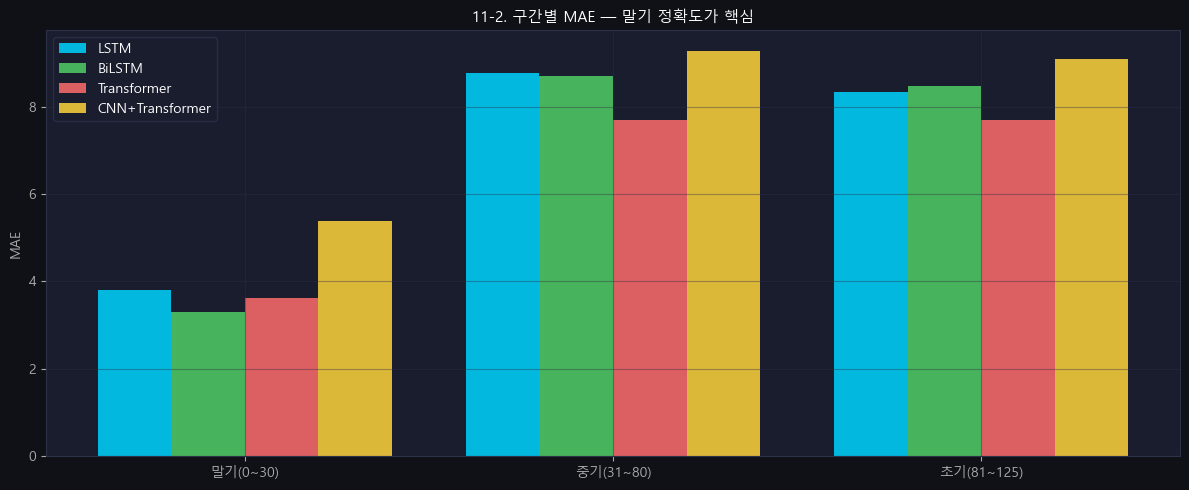

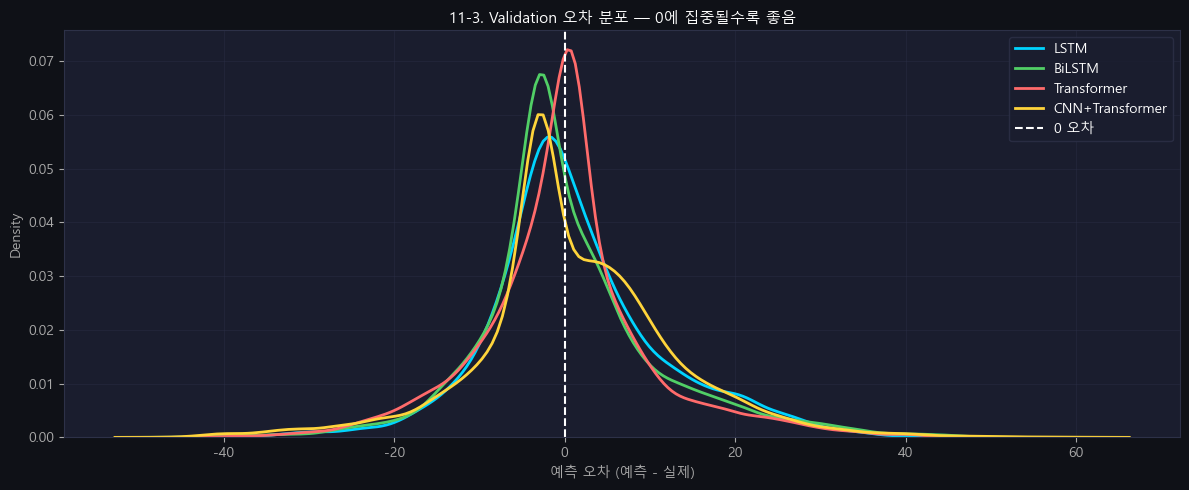

📄 구간별 MAE 저장: results_dl\validation_segment_mae_dl.csv


In [18]:
print('=== 11. 잔차 분석 ===')

# ── Scatter 잔차 (Validation 전체) ────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 14))
fig.suptitle(f'11. 잔차 분석 — Validation 세트 ({len(y_val):,}행)', fontsize=13, fontweight='bold')

for ax, mname in zip(axes.flat, MODEL_NAMES):
    pred = clip_rul(predict_np(BEST_MODELS[mname], X_val))
    resid = pred - y_val
    sc = ax.scatter(y_val, pred, c=resid, cmap='RdYlGn_r',
                    alpha=0.25, s=3, vmin=-40, vmax=40)
    ax.plot([0, 125], [0, 125], color='white', lw=1.5, ls='--')
    m = get_metrics(y_val, pred)
    ax.set_title(f'{mname}\nRMSE={m["RMSE"]:.2f}  R²={m["R2"]:.3f}')
    ax.set_xlabel('실제 RUL'); ax.set_ylabel('예측 RUL')
    ax.set_facecolor(BG2)
    plt.colorbar(sc, ax=ax, label='잔차')

plt.tight_layout(); plt.show()

# ── 구간별 MAE (말기/중기/초기) ───────────────────────────────────────────────
bins   = [0, 30, 80, 125]
labels = ['말기(0~30)', '중기(31~80)', '초기(81~125)']
rul_cat = pd.cut(y_val, bins=bins, labels=labels)

seg_rows = []
for mname in MODEL_NAMES:
    pred = clip_rul(predict_np(BEST_MODELS[mname], X_val))
    row  = {'모델': mname}
    for seg in labels:
        mask = (rul_cat == seg)
        row[seg] = round(mean_absolute_error(y_val[mask], pred[mask]), 2) if mask.sum() > 0 else np.nan
    seg_rows.append(row)

seg_df = pd.DataFrame(seg_rows).set_index('모델')
print('--- 구간별 MAE (Validation) ---')
display(seg_df.style.background_gradient(cmap='RdYlGn_r').format('{:.2f}'))

fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(labels)); width = 0.2
for i, mname in enumerate(MODEL_NAMES):
    vals = [seg_df.loc[mname, seg] for seg in labels]
    ax.bar(x + i*width, vals, width, label=mname, color=MODEL_COLORS[mname], alpha=0.85)
ax.set_xticks(x + width*1.5); ax.set_xticklabels(labels)
ax.set_title('11-2. 구간별 MAE — 말기 정확도가 핵심'); ax.set_ylabel('MAE')
ax.legend(); ax.set_facecolor(BG2)
plt.tight_layout(); plt.show()

# ── 오차 KDE ─────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))
for mname in MODEL_NAMES:
    pred = clip_rul(predict_np(BEST_MODELS[mname], X_val))
    errs = pred - y_val
    sns.kdeplot(errs, ax=ax, fill=False, lw=2, label=mname, color=MODEL_COLORS[mname])
ax.axvline(0, color='white', lw=1.5, ls='--', label='0 오차')
ax.set_title('11-3. Validation 오차 분포 — 0에 집중될수록 좋음')
ax.set_xlabel('예측 오차 (예측 - 실제)'); ax.legend(); ax.set_facecolor(BG2)
plt.tight_layout(); plt.show()

seg_path = os.path.join(RESULT_DIR, 'validation_segment_mae_dl.csv')
seg_df.to_csv(seg_path, encoding='utf-8-sig')
print(f'📄 구간별 MAE 저장: {seg_path}')


## 12. 모델 해석 — Attention 가중치 & Gradient Saliency

| 해석 방법 | 적용 모델 | 내용 |
|-----------|-----------|------|
| **Gradient Saliency** | LSTM, BiLSTM | 입력 각 timestep×feature에 대한 출력 기울기 → 중요도 |
| **Attention 가중치** | Transformer, CNN+Transformer | 마지막 Encoder 레이어의 self-attention 가중치 시각화 |


=== 12. 모델 해석 ===
대표 샘플 index=26  실제 RUL=0


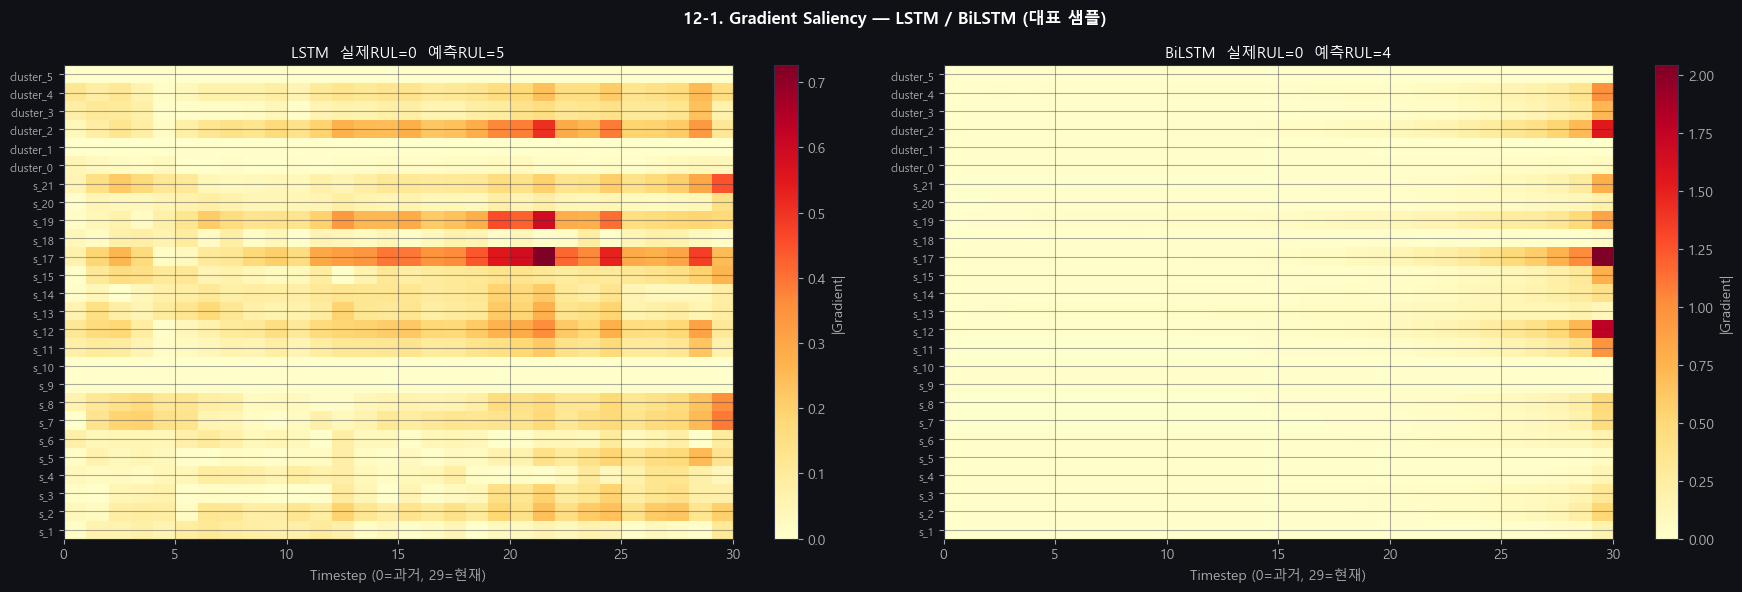

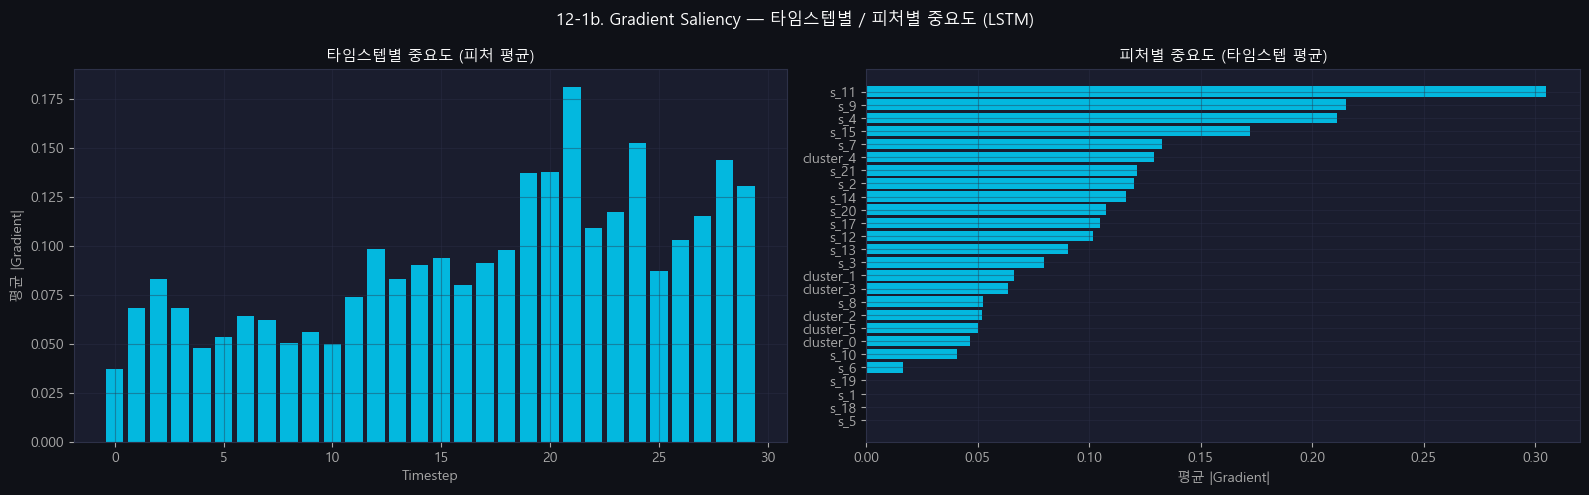

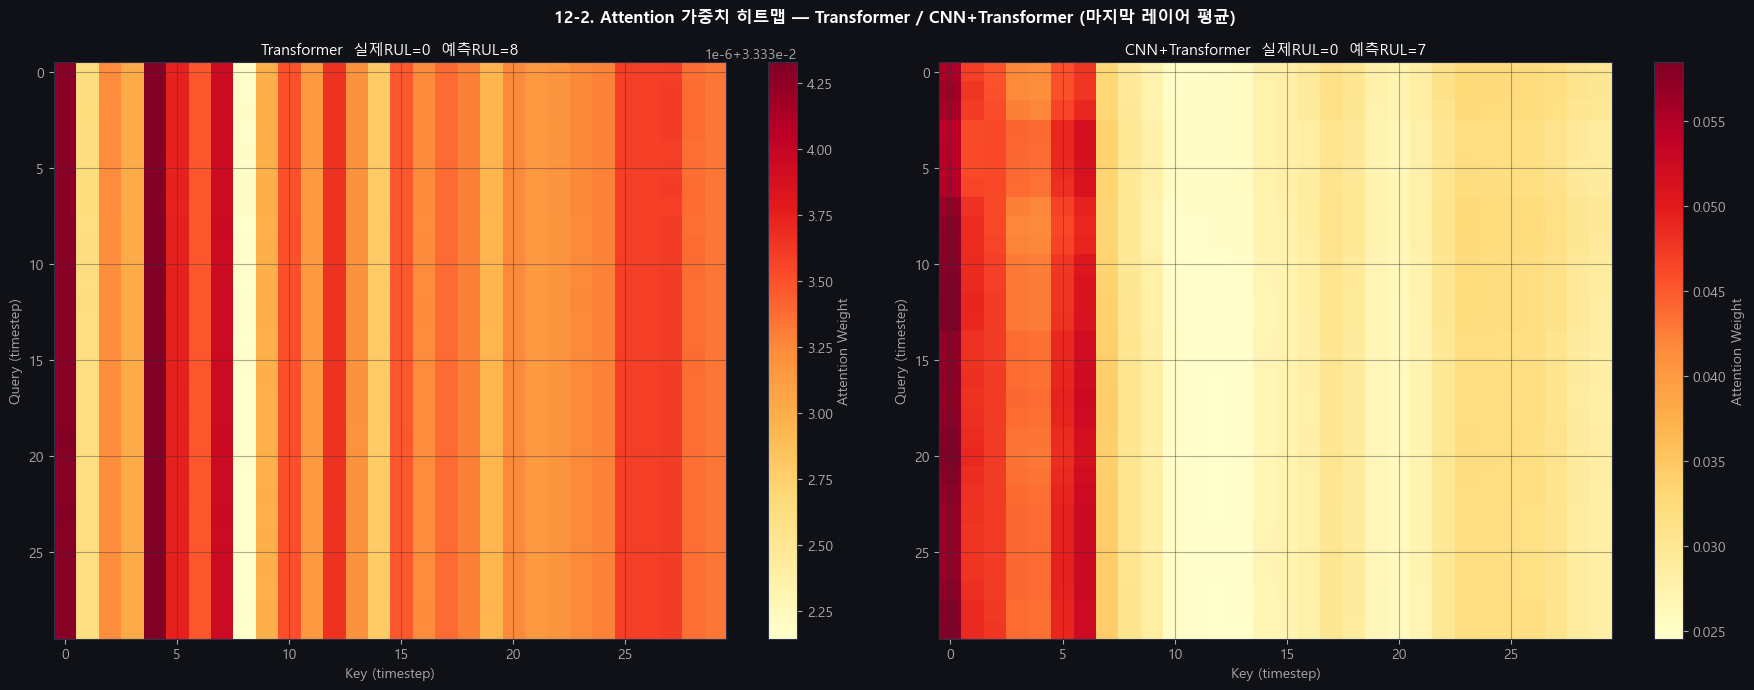

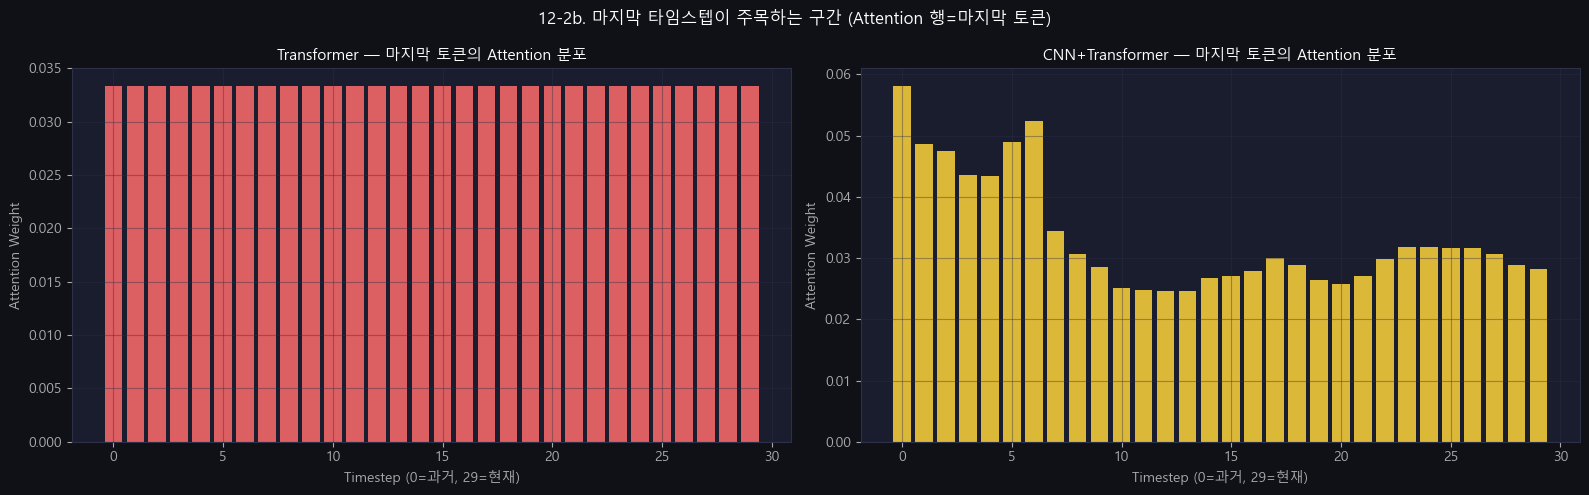

✅ 모델 해석 완료


In [19]:
print('=== 12. 모델 해석 ===')

# ── 공통: 대표 샘플 선택 (val_eval 기준 중간 RUL) ─────────────────────────────
mid_idx = int(np.argsort(y_val_eval)[len(y_val_eval) // 2])
sample_X  = torch.tensor(X_val_eval[mid_idx:mid_idx+1], dtype=torch.float32).to(DEVICE)
sample_rul = y_val_eval[mid_idx]
print(f'대표 샘플 index={mid_idx}  실제 RUL={sample_rul:.0f}')

# ─────────────────────────────────────────────────────────────────────────────
# 12-1. Gradient Saliency (LSTM / BiLSTM)
# ─────────────────────────────────────────────────────────────────────────────
def gradient_saliency(model, x_tensor):
    """
    Returns
    -------
    saliency : ndarray (window_size, n_features) — abs gradient
    """
    model.eval()
    x = x_tensor.clone().detach().requires_grad_(True)
    pred = model(x)
    pred.backward()
    return x.grad.abs().squeeze(0).cpu().numpy()

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle('12-1. Gradient Saliency — LSTM / BiLSTM (대표 샘플)', fontsize=12, fontweight='bold')

for ax, mname in zip(axes, ['LSTM', 'BiLSTM']):
    sal = gradient_saliency(BEST_MODELS[mname], sample_X)  # (T, F)
    im  = ax.imshow(sal.T, aspect='auto', cmap='YlOrRd',
                    extent=[0, WINDOW_SIZE, -0.5, N_FEATURES-0.5])
    ax.set_yticks(range(N_FEATURES))
    ax.set_yticklabels(DL_FEATURES, fontsize=8)
    ax.set_xlabel('Timestep (0=과거, 29=현재)')
    ax.set_title(f'{mname}  실제RUL={sample_rul:.0f}  '
                 f'예측RUL={clip_rul(predict_np(BEST_MODELS[mname], X_val_eval[mid_idx:mid_idx+1]))[0]:.0f}')
    plt.colorbar(im, ax=ax, label='|Gradient|')
    ax.set_facecolor(BG2)

plt.tight_layout(); plt.show()

# ── 타임스텝별 중요도 (평균) ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('12-1b. Gradient Saliency — 타임스텝별 / 피처별 중요도 (LSTM)', fontsize=12)
sal_lstm = gradient_saliency(BEST_MODELS['LSTM'], sample_X)

axes[0].bar(range(WINDOW_SIZE), sal_lstm.mean(axis=1), color=MODEL_COLORS['LSTM'], alpha=0.85)
axes[0].set_xlabel('Timestep'); axes[0].set_ylabel('평균 |Gradient|')
axes[0].set_title('타임스텝별 중요도 (피처 평균)'); axes[0].set_facecolor(BG2)

feat_imp = sal_lstm.mean(axis=0)
order = np.argsort(feat_imp)[::-1]
axes[1].barh([DL_FEATURES[i] for i in order[::-1]],
             feat_imp[order[::-1]], color=MODEL_COLORS['LSTM'], alpha=0.85)
axes[1].set_xlabel('평균 |Gradient|')
axes[1].set_title('피처별 중요도 (타임스텝 평균)'); axes[1].set_facecolor(BG2)
plt.tight_layout(); plt.show()

# ─────────────────────────────────────────────────────────────────────────────
# 12-2. Attention 가중치 (Transformer / CNN+Transformer)
# ─────────────────────────────────────────────────────────────────────────────
def get_attention_weights(model, x_tensor):
    """
    TransformerEncoderLayer의 self-attention 가중치 추출 (마지막 레이어)
    Returns: ndarray (nhead, T, T) 또는 (T, T) 평균
    """
    attn_weights = []

    def hook_fn(module, inp, out):
        # TransformerEncoderLayer: out은 (x,) 또는 (x, attn_weights)
        # norm_first=True 구조에서 attn 추출은 hook으로 처리
        pass

    # PyTorch TransformerEncoderLayer에서 attention 출력 직접 추출
    model.eval()
    attn_maps = []

    # 마지막 encoder layer의 self_attn에 hook 등록
    last_layer = list(model.encoder.layers)[-1]

    def attn_hook(module, input, output):
        # MultiheadAttention forward: output = (attn_output, attn_weights)
        # need_weights=True 인 경우만 반환
        pass

    # forward 시 attn_weight 반환하도록 임시 패치
    with torch.no_grad():
        if hasattr(model, 'input_proj'):
            x = model.pos_enc(model.input_proj(x_tensor))
        elif hasattr(model, 'cnn'):
            x = model.cnn(x_tensor.permute(0, 2, 1)).permute(0, 2, 1)
            x = model.pos_enc(x)
        else:
            x = x_tensor

        # 레이어별로 수동 통과하여 마지막 레이어에서 attn 추출
        for i, layer in enumerate(model.encoder.layers):
            if i < len(model.encoder.layers) - 1:
                x = layer(x)
            else:
                # 마지막 레이어: need_weights=True로 self_attn 호출
                x_norm = layer.norm1(x) if layer.norm_first else x
                attn_out, attn_w = layer.self_attn(
                    x_norm, x_norm, x_norm, need_weights=True, average_attn_weights=False
                )
                attn_maps.append(attn_w.squeeze(0).cpu().numpy())  # (nhead, T, T)

    return attn_maps[0] if attn_maps else None

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('12-2. Attention 가중치 히트맵 — Transformer / CNN+Transformer (마지막 레이어 평균)',
             fontsize=12, fontweight='bold')

for ax, mname in zip(axes, ['Transformer', 'CNN+Transformer']):
    attn = get_attention_weights(BEST_MODELS[mname], sample_X)
    if attn is not None:
        attn_mean = attn.mean(axis=0)  # (T, T) — nhead 평균
        im = ax.imshow(attn_mean, cmap='YlOrRd', aspect='auto')
        ax.set_xlabel('Key (timestep)'); ax.set_ylabel('Query (timestep)')
        ax.set_title(f'{mname}  실제RUL={sample_rul:.0f}  '
                     f'예측RUL={clip_rul(predict_np(BEST_MODELS[mname], X_val_eval[mid_idx:mid_idx+1]))[0]:.0f}')
        plt.colorbar(im, ax=ax, label='Attention Weight')
        ax.set_facecolor(BG2)
    else:
        ax.text(0.5, 0.5, 'Attention 추출 실패\n(모델 구조 확인 필요)',
                ha='center', va='center', transform=ax.transAxes, color=WHITE)
        ax.set_facecolor(BG2)

plt.tight_layout(); plt.show()

# ── 마지막 타임스텝이 받는 attention (query=마지막, key=전체) ─────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('12-2b. 마지막 타임스텝이 주목하는 구간 (Attention 행=마지막 토큰)', fontsize=12)

for ax, mname in zip(axes, ['Transformer', 'CNN+Transformer']):
    attn = get_attention_weights(BEST_MODELS[mname], sample_X)
    if attn is not None:
        last_row = attn.mean(axis=0)[-1, :]   # 마지막 쿼리가 각 키에 주는 attention
        ax.bar(range(WINDOW_SIZE), last_row, color=MODEL_COLORS[mname], alpha=0.85)
        ax.set_xlabel('Timestep (0=과거, 29=현재)')
        ax.set_ylabel('Attention Weight')
        ax.set_title(f'{mname} — 마지막 토큰의 Attention 분포')
        ax.set_facecolor(BG2)

plt.tight_layout(); plt.show()
print('✅ 모델 해석 완료')


## 13. 엔진별 RUL 예측 곡선 — Validation 대표 엔진

=== 13. 엔진별 RUL 예측 곡선 ===


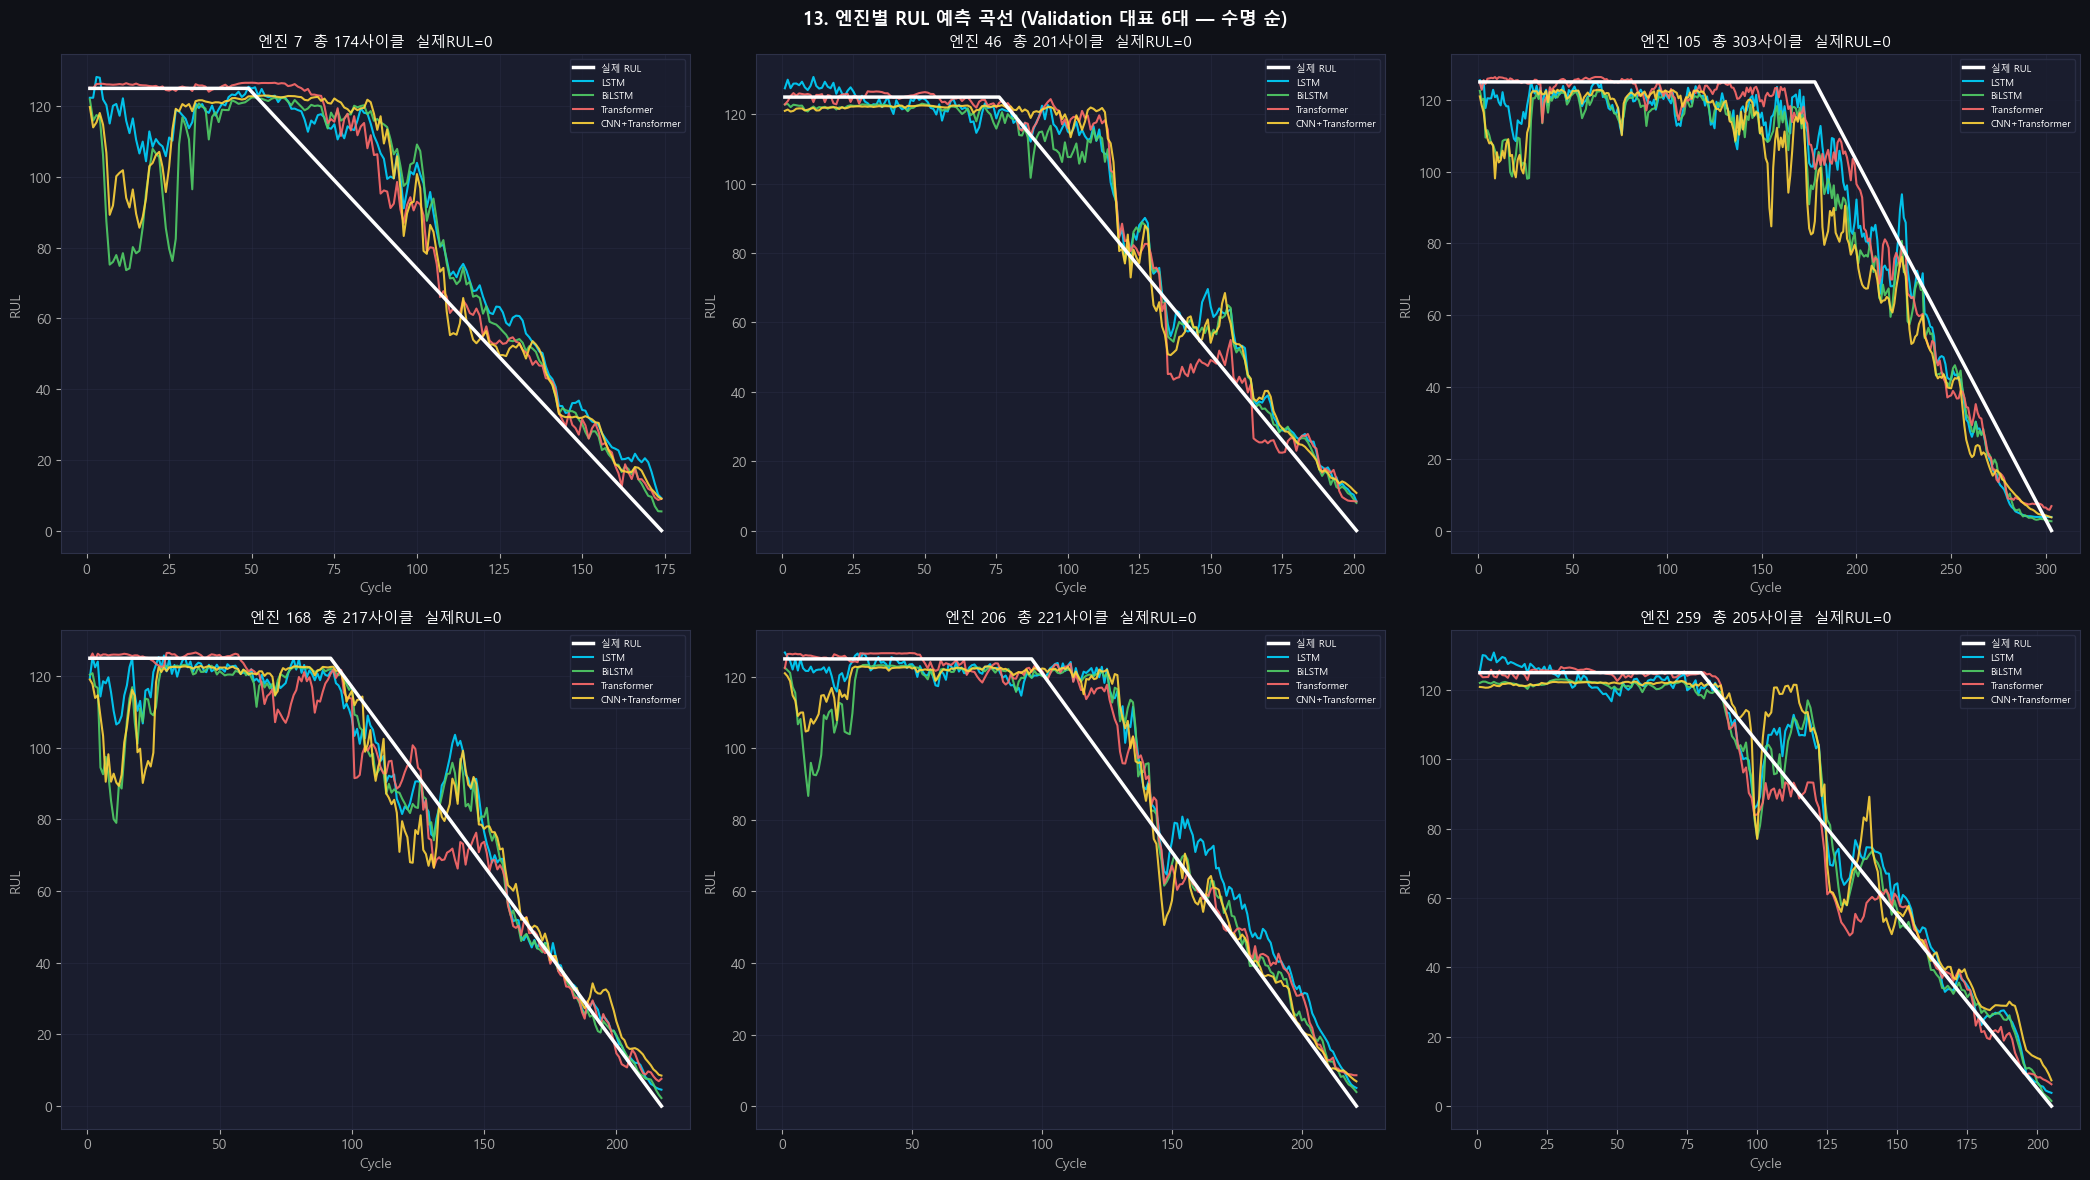

✅ 엔진별 RUL 예측 곡선 완료


In [20]:
print('=== 13. 엔진별 RUL 예측 곡선 ===')

# val_eval 엔진 중 수명 순으로 대표 6대 선택
rul_sort = np.argsort(y_val_eval)
n_sel = min(6, len(val_eval_units))
sel_indices = np.linspace(0, len(rul_sort)-1, n_sel, dtype=int)
sel_units = val_eval_units[rul_sort[sel_indices]]

fig, axes = plt.subplots(2, 3, figsize=(21, 12))
fig.suptitle('13. 엔진별 RUL 예측 곡선 (Validation 대표 6대 — 수명 순)', fontsize=13, fontweight='bold')

for ax, uid in zip(axes.flat, sel_units):
    udf  = valid_ml[valid_ml['unit_nr'] == uid].sort_values('time_cycles').reset_index(drop=True)
    n    = len(udf)
    true_rul = udf['RUL'].values

    # 각 사이클마다 예측: 가장 최근 WINDOW_SIZE 사이클 슬라이딩
    preds_all = {m: [] for m in MODEL_NAMES}
    for t in range(n):
        start = max(0, t - WINDOW_SIZE + 1)
        seg   = udf[DL_FEATURES].values[start:t+1].astype(np.float32)
        if len(seg) < WINDOW_SIZE:
            pad = np.zeros((WINDOW_SIZE - len(seg), N_FEATURES), dtype=np.float32)
            seg = np.vstack([pad, seg])
        x_t = seg[np.newaxis]  # (1, W, F)
        for m in MODEL_NAMES:
            preds_all[m].append(float(clip_rul(predict_np(BEST_MODELS[m], x_t))[0]))

    ax.plot(udf['time_cycles'], true_rul, color='white', lw=2.5, label='실제 RUL', zorder=5)
    for m in MODEL_NAMES:
        ax.plot(udf['time_cycles'], preds_all[m], color=MODEL_COLORS[m],
                lw=1.5, alpha=0.9, label=m)
    ax.set_title(f'엔진 {uid}  총 {n}사이클  실제RUL={true_rul[-1]:.0f}')
    ax.set_xlabel('Cycle'); ax.set_ylabel('RUL')
    ax.legend(loc='upper right', fontsize=7); ax.set_facecolor(BG2)

plt.tight_layout(); plt.show()
print('✅ 엔진별 RUL 예측 곡선 완료')


## 14. NASA Score 상세 분석

=== 14. NASA Score 상세 분석 ===


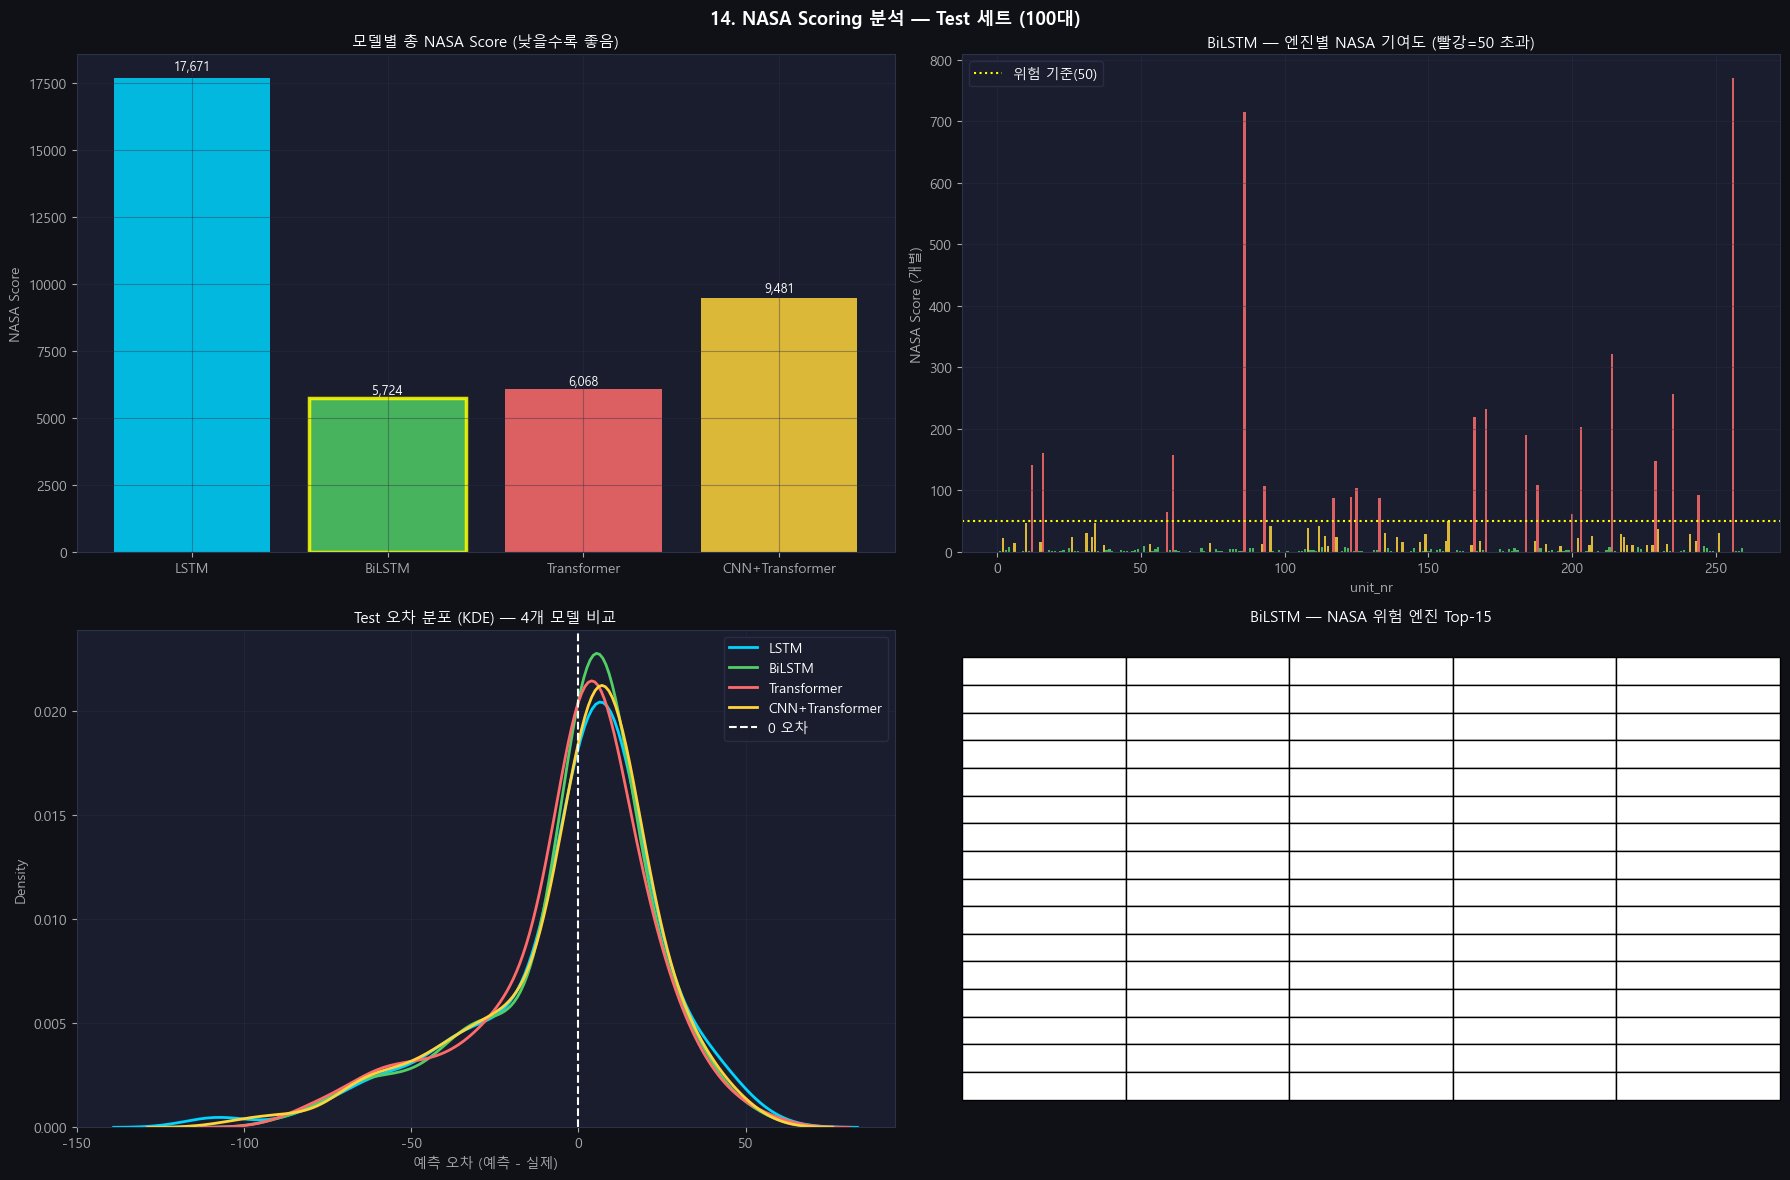

📄 NASA 위험 엔진 저장: results_dl\nasa_risk_engines_dl.csv

--- DL 모델 성능 요약 ---
  LSTM                : Test RMSE=28.415  Test NASA=17670.9  Val NASA(eval)=   30.1
  BiLSTM              : Test RMSE=25.684  Test NASA= 5724.3  Val NASA(eval)=   20.6
  Transformer         : Test RMSE=26.127  Test NASA= 6068.1  Val NASA(eval)=   55.2
  CNN+Transformer     : Test RMSE=27.199  Test NASA= 9480.7  Val NASA(eval)=   67.1


In [21]:
print('=== 14. NASA Score 상세 분석 ===')

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('14. NASA Scoring 분석 — Test 세트 (100대)', fontsize=13, fontweight='bold')

# ── 모델별 총 NASA Score ─────────────────────────────────────────────────────
ax = axes[0, 0]
scores = {m: ALL_RESULTS[m]['test_metrics']['NASA_Score'] for m in MODEL_NAMES}
bars   = ax.bar(scores.keys(), scores.values(),
                color=[MODEL_COLORS[m] for m in scores], alpha=0.85)
ax.set_title('모델별 총 NASA Score (낮을수록 좋음)')
ax.set_ylabel('NASA Score')
best_i = np.argmin(list(scores.values()))
list(bars)[best_i].set_edgecolor('yellow'); list(bars)[best_i].set_linewidth(2.5)
for bar, v in zip(bars, scores.values()):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()*1.01,
            f'{v:,.0f}', ha='center', va='bottom', fontsize=9, color=WHITE)
ax.set_facecolor(BG2)

# ── 최고 모델 엔진별 기여도 ──────────────────────────────────────────────────
ax = axes[0, 1]
pred_best = test_pred_all[best_model_name]
d = pred_best - y_test
per_ns = np.where(d < 0, np.exp(-d/13)-1, np.exp(d/10)-1)
colors_ns = [C[1] if v > 50 else (C[3] if v > 10 else C[2]) for v in per_ns]
ax.bar(np.arange(1, len(per_ns)+1), per_ns, color=colors_ns, alpha=0.85)
ax.axhline(50, color='yellow', lw=1.5, ls=':', label='위험 기준(50)')
ax.set_title(f'{best_model_name} — 엔진별 NASA 기여도 (빨강=50 초과)')
ax.set_xlabel('unit_nr'); ax.set_ylabel('NASA Score (개별)')
ax.legend(); ax.set_facecolor(BG2)

# ── 오차 분포 비교 (KDE) ─────────────────────────────────────────────────────
ax = axes[1, 0]
for m in MODEL_NAMES:
    errs = test_pred_all[m] - y_test
    sns.kdeplot(errs, ax=ax, lw=2, label=m, color=MODEL_COLORS[m])
ax.axvline(0, color='white', lw=1.5, ls='--', label='0 오차')
ax.set_title('Test 오차 분포 (KDE) — 4개 모델 비교')
ax.set_xlabel('예측 오차 (예측 - 실제)')
ax.legend(); ax.set_facecolor(BG2)

# ── NASA 위험 엔진 Top-15 표 ─────────────────────────────────────────────────
ax = axes[1, 1]
risk_df = pd.DataFrame({
    'unit': np.arange(1, len(y_test)+1),
    'actual_rul': y_test.astype(int),
    'pred_rul': np.round(pred_best, 1),
    'error': np.round(d, 1),
    'nasa': np.round(per_ns, 1),
}).sort_values('nasa', ascending=False).head(15)

ax.axis('off')
tbl = ax.table(cellText=risk_df.values, colLabels=risk_df.columns, loc='center')
tbl.auto_set_font_size(False); tbl.set_fontsize(8); tbl.scale(1, 1.4)
ax.set_title(f'{best_model_name} — NASA 위험 엔진 Top-15')

plt.tight_layout(); plt.show()

risk_path = os.path.join(RESULT_DIR, 'nasa_risk_engines_dl.csv')
risk_df.to_csv(risk_path, index=False, encoding='utf-8-sig')
print(f'📄 NASA 위험 엔진 저장: {risk_path}')

# ── ML vs DL 비교 안내 ────────────────────────────────────────────────────────
print('\n--- DL 모델 성능 요약 ---')
for mname in MODEL_NAMES:
    res = ALL_RESULTS[mname]
    print(f'  {mname:20s}: Test RMSE={res["test_metrics"]["RMSE"]:.3f}  '
          f'Test NASA={res["test_metrics"]["NASA_Score"]:7.1f}  '
          f'Val NASA(eval)={res["val_eval_nasa"]:7.1f}')


## 15. 모델 및 산출물 저장

In [22]:
print('=== 15. 모델 및 산출물 저장 ===')

# ── PyTorch 모델 저장 ─────────────────────────────────────────────────────────
for mname, model in BEST_MODELS.items():
    state_path = os.path.join(MODEL_DIR, f'FD001_{mname}_best.pt')
    arch_path  = os.path.join(MODEL_DIR, f'FD001_{mname}_arch.json')
    torch.save(model.state_dict(), state_path)
    with open(arch_path, 'w') as f:
        json.dump(ALL_RESULTS[mname]['params'], f, indent=2)
    size_kb = os.path.getsize(state_path) / 1024
    print(f'  저장: {state_path} ({size_kb:.1f} KB)')

# ── 요약 JSON ─────────────────────────────────────────────────────────────────
summary = {
    'best_model'       : best_model_name,
    'selection_rule'   : 'Val NASA(eval) → Val RMSE',
    'random_state'     : RANDOM_STATE,
    'window_size'      : WINDOW_SIZE,
    'n_features'       : N_FEATURES,
    'dl_features'      : DL_FEATURES,
    'models'           : {
        m: {
            'params'         : ALL_RESULTS[m]['params'],
            'n_params'       : ALL_RESULTS[m]['n_params'],
            'best_epoch'     : ALL_RESULTS[m]['best_epoch'],
            'val_eval_nasa'  : round(ALL_RESULTS[m]['val_eval_nasa'], 1),
            'val_metrics'    : {k: round(v, 4) for k, v in ALL_RESULTS[m]['val_metrics'].items()},
            'test_metrics'   : {k: round(v, 4) for k, v in ALL_RESULTS[m]['test_metrics'].items()},
            'fit_seconds'    : round(ALL_RESULTS[m]['fit_seconds'], 1),
        }
        for m in MODEL_NAMES
    }
}
summary_path = os.path.join(RESULT_DIR, 'best_model_summary_dl.json')
with open(summary_path, 'w', encoding='utf-8') as f:
    json.dump(summary, f, ensure_ascii=False, indent=2)

# ── MLflow 아티팩트 업로드 ────────────────────────────────────────────────────
if mlflow.active_run() is not None:
    for p in [result_csv_path, test_detail_path, seg_path, risk_path, summary_path]:
        if os.path.exists(p):
            mlflow.log_artifact(p)
    mlflow.log_params({'best_model': best_model_name})
    mlflow.end_run()
    print('✅ MLflow 부모 run 종료')

print(f'\n✅ 저장 완료')
print(f'  모델 폴더   : {os.path.abspath(MODEL_DIR)}')
print(f'  결과 폴더   : {os.path.abspath(RESULT_DIR)}')
print(f'  MLflow 폴더 : {os.path.abspath(MLFLOW_DIR)}')


=== 15. 모델 및 산출물 저장 ===
  저장: models_dl\FD001_LSTM_best.pt (112.1 KB)
  저장: models_dl\FD001_BiLSTM_best.pt (3753.4 KB)
  저장: models_dl\FD001_Transformer_best.pt (684.2 KB)
  저장: models_dl\FD001_CNN+Transformer_best.pt (2398.8 KB)
✅ MLflow 부모 run 종료

✅ 저장 완료
  모델 폴더   : c:\python_course\4project_cmapss\SH\models_dl
  결과 폴더   : c:\python_course\4project_cmapss\SH\results_dl
  MLflow 폴더 : c:\python_course\4project_cmapss\SH\mlruns


## 16. 최종 요약 리포트

In [23]:
print('=' * 90)
print(' NASA C-MAPSS FD001 — 딥러닝 최종 요약 (LSTM / BiLSTM / Transformer / CNN+Transformer)')
print('=' * 90)

print('\n[데이터]')
print(f'  Sub-train   : {len(X_sub):,}개 윈도우 (엔진 {valid_ml["unit_nr"].nunique()}대 제외 나머지)')
print(f'  Validation  : {len(X_val):,}개 윈도우')
print(f'  Val-eval    : {len(X_val_eval)}개 (엔진별 마지막 윈도우 — NASA Score 기준)')
print(f'  Test        : {len(X_test)}개 (엔진 100대 마지막 윈도우)')
print(f'  피처 수     : {N_FEATURES}개  |  Window: {WINDOW_SIZE}사이클  |  Step: 1')

print('\n[모델 선택 기준]')
print('  1) Val NASA Score — 엔진별 마지막 윈도우 기준 (Test와 동일한 방식)')
print('  2) Val RMSE (동률 시 보조)')
print('  ※ Test는 최종 확인용이며 모델 선택에 사용하지 않음')

print('\n[최종 순위 — Val NASA(eval) 기준]')
rank_view = result_df[['선정순위','모델','Val NASA(eval)','Val RMSE',
                        'Test NASA','Test RMSE','파라미터 수','학습시간(초)']]
display(rank_view)

print(f'\n[🏆 최고 모델] {best_model_name}')
bm = ALL_RESULTS[best_model_name]
print(f'  최적 파라미터      : {bm["params"]}')
print(f'  파라미터 수        : {bm["n_params"]:,}')
print(f'  Best Epoch         : {bm["best_epoch"]}')
print(f'  Val NASA(eval)     : {bm["val_eval_nasa"]:.1f}')
print(f'  Validation (full)  : RMSE={bm["val_metrics"]["RMSE"]:.3f}  '
      f'MAE={bm["val_metrics"]["MAE"]:.3f}  R²={bm["val_metrics"]["R2"]:.4f}')
print(f'  Test               : RMSE={bm["test_metrics"]["RMSE"]:.3f}  '
      f'MAE={bm["test_metrics"]["MAE"]:.3f}  R²={bm["test_metrics"]["R2"]:.4f}  '
      f'NASA={bm["test_metrics"]["NASA_Score"]:.1f}')

print('\n[모델별 주요 특성 비교]')
char_df = pd.DataFrame({
    '모델'       : ['LSTM', 'BiLSTM', 'Transformer', 'CNN+Transformer'],
    '순방향'     : ['✓', '✓', '✓', '✓'],
    '역방향'     : ['✗', '✓', '✗', '✗'],
    'Attention'  : ['✗', '✗', '✓', '✓'],
    'CNN 국소패턴': ['✗', '✗', '✗', '✓'],
    '파라미터 수': [f'{ALL_RESULTS[m]["n_params"]:,}' for m in
                  ['LSTM','BiLSTM','Transformer','CNN+Transformer']],
}).set_index('모델')
display(char_df)

print('\n[MLflow 활용]')
print(f'  Tracking URI : {mlflow.get_tracking_uri()}')
print(f'  Experiment   : {EXPERIMENT_NAME}')
print('  기록 항목     : 파라미터 / Val·Test 메트릭 / 모델 .pt / CSV 아티팩트')

print('\n[다음 단계 추천]')
print('  1. ML 노트북 결과와 DL 결과 직접 RMSE / NASA Score 비교 정리')
print('  2. GRU / TCN / Mamba 등 추가 아키텍처 실험')
print('  3. FD002~FD004 확장 (다중 조건 / 다중 결함)')
print('  4. 앙상블: 최고 DL + 최고 ML 예측 평균')
print('  5. 온라인 추론 파이프라인: scaler.pkl + best .pt → TorchScript export')
print('=' * 90)


 NASA C-MAPSS FD001 — 딥러닝 최종 요약 (LSTM / BiLSTM / Transformer / CNN+Transformer)

[데이터]
  Sub-train   : 37,432개 윈도우 (엔진 52대 제외 나머지)
  Validation  : 8,787개 윈도우
  Val-eval    : 52개 (엔진별 마지막 윈도우 — NASA Score 기준)
  Test        : 259개 (엔진 100대 마지막 윈도우)
  피처 수     : 26개  |  Window: 30사이클  |  Step: 1

[모델 선택 기준]
  1) Val NASA Score — 엔진별 마지막 윈도우 기준 (Test와 동일한 방식)
  2) Val RMSE (동률 시 보조)
  ※ Test는 최종 확인용이며 모델 선택에 사용하지 않음

[최종 순위 — Val NASA(eval) 기준]


,선정순위,모델,Val NASA(eval),Val RMSE,Test NASA,Test RMSE,파라미터 수,학습시간(초)
0,1,BiLSTM,20.6,10.715,5724.3,25.684,"958,529",2128.0
1,2,LSTM,30.1,10.533,17670.9,28.415,"27,777",78.2
2,3,Transformer,55.2,10.131,6068.1,26.127,"137,857",1092.9
3,4,CNN+Transformer,67.1,11.705,9480.7,27.199,"544,513",538.3



[🏆 최고 모델] BiLSTM
  최적 파라미터      : {'hidden_size': 128, 'num_layers': 3, 'dropout': 0.20351199264000677, 'fc_size': 32, 'lr': 0.0012399967836846098, 'weight_decay': 3.5856126103453987e-06}
  파라미터 수        : 958,529
  Best Epoch         : 37
  Val NASA(eval)     : 20.6
  Validation (full)  : RMSE=10.715  MAE=7.594  R²=0.9337
  Test               : RMSE=25.684  MAE=18.247  R²=0.7719  NASA=5724.3

[모델별 주요 특성 비교]


,순방향,역방향,Attention,CNN 국소패턴,파라미터 수
모델,,,,,
LSTM,✓,✗,✗,✗,"27,777"
BiLSTM,✓,✓,✗,✗,"958,529"
Transformer,✓,✗,✓,✗,"137,857"
CNN+Transformer,✓,✗,✓,✓,"544,513"



[MLflow 활용]
  Tracking URI : file:///C:/python_course/4project_cmapss/SH/mlruns
  Experiment   : CMAPSS_FD002_DL
  기록 항목     : 파라미터 / Val·Test 메트릭 / 모델 .pt / CSV 아티팩트

[다음 단계 추천]
  1. ML 노트북 결과와 DL 결과 직접 RMSE / NASA Score 비교 정리
  2. GRU / TCN / Mamba 등 추가 아키텍처 실험
  3. FD002~FD004 확장 (다중 조건 / 다중 결함)
  4. 앙상블: 최고 DL + 최고 ML 예측 평균
  5. 온라인 추론 파이프라인: scaler.pkl + best .pt → TorchScript export
